In [7]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1. Define the LiPF6 molecule (neutral Li+ · PF6– pair)
#    - P–F bond length ≈ 1.57 Å (ideal octahedron)
#    - Li+ placed 3 Å from P along +x for simplicity
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
P        -0.000000        0.000000        0.488729
F         0.000000        1.168427       -0.784020
F        -0.000000       -1.177740        1.573458
F        -1.619481        0.000000        0.381474
F         1.619481       -0.000000        0.381474
F        -0.000000       -1.168427       -0.784020
F         0.000000        1.177740        1.573458
Na        0.000000        0.000000       -2.582486
'''
mol.basis  = '631g*'         # minimal basis for quick tests
mol.charge = 0                # Li+ + PF6– → neutral overall
mol.spin   = 0                # closed‑shell RHF
mol.build()

# ──────────────────────────────────────────────────────────────
# 2. Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3. Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies  = mf.mo_energy
n_electrons  = mol.nelectron

print("\n📊  Orbital Energies (LiPF₆):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4. Simple active‑space suggestions
#    • Freeze very low‑lying core orbitals (e < −0.8 Ha)
#    • Remove high virtuals            (e >  +0.5 Ha)
#    Adjust thresholds to taste!
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.8
virtual_threshold =  0.5

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")


converged SCF energy = -1099.4366235968

📊  Orbital Energies (LiPF₆):
  Orbital  0 : -80.235931 Ha   →  occupied
  Orbital  1 : -40.544803 Ha   →  occupied
  Orbital  2 : -26.282070 Ha   →  occupied
  Orbital  3 : -26.282068 Ha   →  occupied
  Orbital  4 : -26.271503 Ha   →  occupied
  Orbital  5 : -26.271501 Ha   →  occupied
  Orbital  6 : -26.270206 Ha   →  occupied
  Orbital  7 : -26.270201 Ha   →  occupied
  Orbital  8 : -7.727325 Ha   →  occupied
  Orbital  9 : -5.628842 Ha   →  occupied
  Orbital 10 : -5.628654 Ha   →  occupied
  Orbital 11 : -5.628190 Ha   →  occupied
  Orbital 12 : -2.857958 Ha   →  occupied
  Orbital 13 : -1.650449 Ha   →  occupied
  Orbital 14 : -1.591059 Ha   →  occupied
  Orbital 15 : -1.585654 Ha   →  occupied
  Orbital 16 : -1.580857 Ha   →  occupied
  Orbital 17 : -1.572111 Ha   →  occupied
  Orbital 18 : -1.569546 Ha   →  occupied
  Orbital 19 : -1.564971 Ha   →  occupied
  Orbital 20 : -1.542341 Ha   →  occupied
  Orbital 21 : -1.538159 Ha   →  occupie

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for LiPF6
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)


# === Step 1: Define the N2 molecule ===
driver = PySCFDriver(
    atom= napf6_geometry,
    basis="631g*",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin Orbitals", es_problem.num_spin_orbitals)
# How many physical electrons (α + β)?
n_alpha, n_beta = es_problem.num_particles
print("Electrons        :", n_alpha + n_beta, f"({n_alpha} α, {n_beta} β)")
no_of_qubit = 2*es_problem.num_spatial_orbitals
print("Number Qubit needed :", no_of_qubit)

# === Step 2: Freeze core + remove high-energy virtuals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 37)),   # Core
    remove_orbitals=list(range(42, es_problem.num_spatial_orbitals))            # Virtual
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Reduce active space (adjust electrons/orbitals as needed) ===
active_transformer = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=4          # 3 orbitals × 2 = 6 qubits
)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Build qubit Hamiltonian ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz and initial state ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)
#ansatz = EfficientSU2(qubit_hamiltonian.num_qubits)

# === Step 6: VQE setup ===
#optimizer = SLSQP(maxiter=1000)
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()

vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

solver = GroundStateEigensolver(mapper, vqe_solver)
result = solver.solve(es_problem_active)

# === Step 7: Output results ===
print("\n Molecule: NaPF6 (active space)")
print(" Qubits used:", qubit_hamiltonian.num_qubits)
print("Particles:", num_particles)
print("Spatial Orbitals:", num_spatial_orbitals)
print("Ground state energy (Hartree):", result.total_energies[0].real)
print("Optimal parameters:", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")

Spatial orbitals : 80
Spin Orbitals 160
Electrons        : 80 (40 α, 40 β)
Number Qubit needed : 160

 Molecule: NaPF6 (active space)
 Qubits used: 8
Particles: (2, 2)
Spatial Orbitals: 4
Ground state energy (Hartree): -1099.1480044625323
Optimal parameters: [ 5.96812309e-05 -2.48854061e-05 -5.33147046e-05  5.63606699e-06
  6.78717895e-05  2.93549483e-05  3.54765685e-06  6.47856903e-05
  1.77817605e-05 -4.29485425e-05 -3.19715200e-05  8.39081120e-06
  4.05583883e-05 -2.65364891e-05 -3.79446628e-04  2.44588430e-05
  1.48232045e-07 -3.72463278e-05 -2.06816380e-05 -1.31684883e-05
  5.49534458e-06  2.44437665e-06  7.04781838e-06  4.14142824e-06
 -2.49275362e-04  2.59261269e-05]


In [12]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.algorithms import QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Step 1: Molecule Geometry ===
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

driver = PySCFDriver(
    atom=napf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + reduce orbitals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 37)),
    remove_orbitals=list(range(43, es_problem.num_spatial_orbitals))
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Active space ===
active_transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=4)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Qubit mapping ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)

# === Step 6: VQE Ground State Solver ===
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

g_solver = GroundStateEigensolver(mapper, vqe_solver)

# === Step 7: Excited State Solver using qEOM ===
qeom_solver = QEOM(g_solver, estimator, "s", EvaluationRule.ALL)  # Use both single and double excitations
result = qeom_solver.solve(es_problem_active)

# === Step 8: Print Results ===
print("\n=== NaPF6 Excited State Energies ===")
energies = [res.real for res in result.total_energies]
ground_state_energy = energies[0]

for i, energy in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_E = energy - ground_state_energy if i > 0 else 0
    print(f"{label} State Energy: {energy:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_E:.6f} Hartree ≈ {delta_E*27.2114:.2f} eV")
    else:
        print()


=== NaPF6 Excited State Energies ===
Ground State Energy: -1099.148004 Hartree
Excited 1 State Energy: -1098.669495 Hartree   ΔE = 0.478509 Hartree ≈ 13.02 eV
Excited 2 State Energy: -1098.669386 Hartree   ΔE = 0.478618 Hartree ≈ 13.02 eV
Excited 3 State Energy: -1098.669340 Hartree   ΔE = 0.478664 Hartree ≈ 13.03 eV
Excited 4 State Energy: -1098.669116 Hartree   ΔE = 0.478889 Hartree ≈ 13.03 eV
Excited 5 State Energy: -1098.619549 Hartree   ΔE = 0.528455 Hartree ≈ 14.38 eV
Excited 6 State Energy: -1098.619468 Hartree   ΔE = 0.528536 Hartree ≈ 14.38 eV
Excited 7 State Energy: -1098.618847 Hartree   ΔE = 0.529158 Hartree ≈ 14.40 eV
Excited 8 State Energy: -1098.618403 Hartree   ΔE = 0.529601 Hartree ≈ 14.41 eV


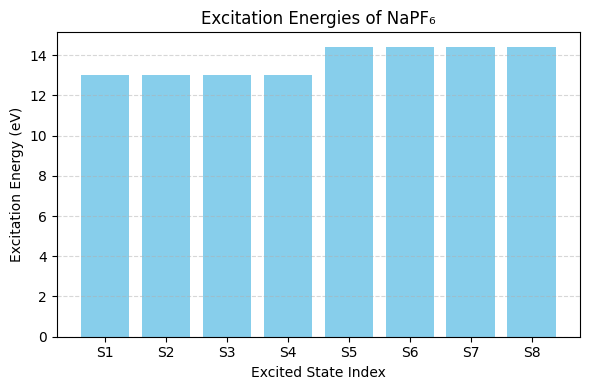

In [13]:
import matplotlib.pyplot as plt

# Assuming you already have this from earlier
energies = [res.real for res in result.total_energies]
ground_energy = energies[0]
delta_E = [(e - ground_energy) * 27.2114 for e in energies[1:]]  # ΔE in eV

# Limit number of excited states shown
n_show = 8
delta_E = delta_E[:n_show]

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(range(1, n_show + 1), delta_E, color="skyblue")
plt.xlabel("Excited State Index")
plt.ylabel("Excitation Energy (eV)")
plt.title("Excitation Energies of NaPF₆")
plt.xticks(range(1, n_show + 1), [f"S{i}" for i in range(1, n_show + 1)])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [17]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.algorithms import QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Step 1: Molecule Geometry ===
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

driver = PySCFDriver(
    atom=napf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + reduce orbitals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 37)),
    remove_orbitals=list(range(43, es_problem.num_spatial_orbitals))
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Active space ===
active_transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Qubit mapping ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)

# === Step 6: VQE Ground State Solver ===
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

g_solver = GroundStateEigensolver(mapper, vqe_solver)

# === Step 7: Excited State Solver using qEOM ===
qeom_solver = QEOM(g_solver, estimator, "sd", EvaluationRule.DIAG)  # Use both single and double excitations
result = qeom_solver.solve(es_problem_active)

# === Step 8: Print Results ===
print("\n=== NaPF6 Excited State Energies ===")
energies = [res.real for res in result.total_energies]
ground_state_energy = energies[0]

for i, energy in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_E = energy - ground_state_energy if i > 0 else 0
    print(f"{label} State Energy: {energy:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_E:.6f} Hartree ≈ {delta_E*27.2114:.2f} eV")
    else:
        print()


=== NaPF6 Excited State Energies ===
Ground State Energy: -1099.148004 Hartree
Excited 1 State Energy: -1098.669495 Hartree   ΔE = 0.478509 Hartree ≈ 13.02 eV
Excited 2 State Energy: -1098.669386 Hartree   ΔE = 0.478618 Hartree ≈ 13.02 eV
Excited 3 State Energy: -1098.669340 Hartree   ΔE = 0.478664 Hartree ≈ 13.03 eV
Excited 4 State Energy: -1098.669116 Hartree   ΔE = 0.478889 Hartree ≈ 13.03 eV
Excited 5 State Energy: -1097.912798 Hartree   ΔE = 1.235206 Hartree ≈ 33.61 eV
Excited 6 State Energy: -1097.900155 Hartree   ΔE = 1.247850 Hartree ≈ 33.96 eV
Excited 7 State Energy: -1097.810494 Hartree   ΔE = 1.337510 Hartree ≈ 36.40 eV
Excited 8 State Energy: -1097.797847 Hartree   ΔE = 1.350157 Hartree ≈ 36.74 eV


In [30]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

driver = PySCFDriver(atom=geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === Step 2: Transform for active space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 37)),
    remove_orbitals=list(range(43, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=3
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Compare Results ===
print("\n=== NumPy (Exact) Excited State Energies of NaPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of NaPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of NaPF6 ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")
#bandgap # in Hartree



=== NumPy (Exact) Excited State Energies of NaPF6 ===
State 0: -1099.174091 Hartree
State 1: -1099.174091 Hartree
State 2: -1099.148004 Hartree
State 3: -1098.995015 Hartree
State 4: -1098.669495 Hartree
State 5: -1098.669495 Hartree
State 6: -1098.669495 Hartree
State 7: -1098.669386 Hartree

=== VQE + qEOM Excited State Energies of NaPF6 ===
Ground State: -1099.148004 Hartree
Excited 1 State: -1098.669495 Hartree   ΔE = 0.478509 Hartree ≈ 13.02 eV
Excited 2 State: -1098.669386 Hartree   ΔE = 0.478618 Hartree ≈ 13.02 eV
Excited 3 State: -1098.669340 Hartree   ΔE = 0.478664 Hartree ≈ 13.03 eV
Excited 4 State: -1098.669116 Hartree   ΔE = 0.478889 Hartree ≈ 13.03 eV
Excited 5 State: -1097.912798 Hartree   ΔE = 1.235206 Hartree ≈ 33.61 eV
Excited 6 State: -1097.900155 Hartree   ΔE = 1.247850 Hartree ≈ 33.96 eV
Excited 7 State: -1097.810494 Hartree   ΔE = 1.337510 Hartree ≈ 36.40 eV
Excited 8 State: -1097.797847 Hartree   ΔE = 1.350157 Hartree ≈ 36.74 eV

=== HOMO and LUMO gap of NaPF6 ==

Running VQE at Na–F distance 1.50 Å ...
Running VQE at Na–F distance 1.75 Å ...
Running VQE at Na–F distance 2.00 Å ...
Running VQE at Na–F distance 2.25 Å ...
Running VQE at Na–F distance 2.50 Å ...
Running VQE at Na–F distance 2.75 Å ...
Running VQE at Na–F distance 3.00 Å ...
Running VQE at Na–F distance 3.25 Å ...
Running VQE at Na–F distance 3.50 Å ...
Running VQE at Na–F distance 3.75 Å ...
Running VQE at Na–F distance 4.00 Å ...
Running VQE at Na–F distance 4.25 Å ...
Running VQE at Na–F distance 4.50 Å ...
Running VQE at Na–F distance 4.75 Å ...
Running VQE at Na–F distance 5.00 Å ...


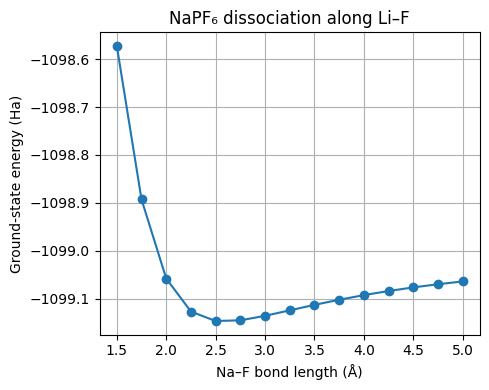

In [ ]:
###############################################################
# Li–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 37))
virtual_trim_start    = 43
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000          # keep modest so sweep finishes
distances             = np.linspace(1.5, 6.0, 18)   # Å, Li–nearest‑F distance
# ------------------------------------------------

def make_geometry(d):
    """Return LiPF6 geometry string with Li along –z at distance d from P."""
    return (
        f"P -0.000000  0.000000  0.488729; "
        f"F  0.000000  1.168427 -0.784020; "
        f"F -0.000000 -1.177740  1.573458; "
        f"F -1.619481  0.000000  0.381474; "
        f"F  1.619481 -0.000000  0.381474; "
        f"F -0.000000 -1.168427 -0.784020; "
        f"F  0.000000  1.177740  1.573458; "
        f"Na 0.000000  0.000000  {-d:6.4f}"
    )

def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob   = driver.run()

    # freeze core + trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals))
    )
    prob = freeze.transform(prob)

    # active space
    active = ActiveSpaceTransformer(num_electrons=active_nelec,
                                    num_spatial_orbitals=active_norb)
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans  = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(Estimator(), ansatz=ans,
              optimizer=COBYLA(maxiter=optimizer_maxiter),
              initial_point=[0.0] * ans.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res    = solver.solve(prob)
    return res.total_energies[0].real

# ---------- sweep distances ----------
energies = []
for d in distances:
    print(f"Running VQE at Na–F distance {d:4.2f} Å ...")
    energies.append(vqe_energy(make_geometry(d)))

# ---------- plot ----------
plt.figure(figsize=(5,4))
plt.plot(distances, energies, "-o")
plt.xlabel("Na–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("NaPF₆ dissociation along Li–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("NaPF6_dissociation_cuve.png", dpi=300)
plt.show()

Running VQE at Na–F distance 1.50 Å ...
Running VQE at Na–F distance 1.76 Å ...
Running VQE at Na–F distance 2.03 Å ...
Running VQE at Na–F distance 2.29 Å ...
Running VQE at Na–F distance 2.56 Å ...
Running VQE at Na–F distance 2.82 Å ...
Running VQE at Na–F distance 3.09 Å ...
Running VQE at Na–F distance 3.35 Å ...
Running VQE at Na–F distance 3.62 Å ...
Running VQE at Na–F distance 3.88 Å ...
Running VQE at Na–F distance 4.15 Å ...
Running VQE at Na–F distance 4.41 Å ...
Running VQE at Na–F distance 4.68 Å ...
Running VQE at Na–F distance 4.94 Å ...
Running VQE at Na–F distance 5.21 Å ...
Running VQE at Na–F distance 5.47 Å ...
Running VQE at Na–F distance 5.74 Å ...
Running VQE at Na–F distance 6.00 Å ...

✅ Saved minimum-energy geometry to NaPF6_min.xyz


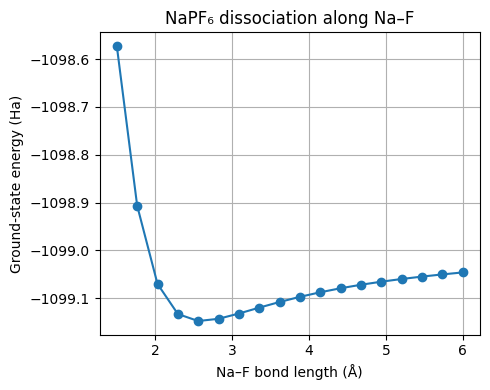

In [ ]:
###############################################################
# Na–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 37))
virtual_trim_start    = 43
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000
distances             = np.linspace(1.5, 6.0, 18)   # 18 points → 1.5 … 6.0 Å
# ------------------------------------------------


def make_geometry(d):
    """Return NaPF6 geometry string with Na along –z at distance d from P."""
    return (
        f"P -0.000000  0.000000  0.488729; "
        f"F  0.000000  1.168427 -0.784020; "
        f"F -0.000000 -1.177740  1.573458; "
        f"F -1.619481  0.000000  0.381474; "
        f"F  1.619481 -0.000000  0.381474; "
        f"F -0.000000 -1.168427 -0.784020; "
        f"F  0.000000  1.177740  1.573458; "
        f"Na 0.000000  0.000000  {-d:6.4f}"
    )


def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob = driver.run()

    # Freeze core and trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals)),
    )
    prob = freeze.transform(prob)

    # Active space
    active = ActiveSpaceTransformer(
        num_electrons=active_nelec, num_spatial_orbitals=active_norb
    )
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(
        Estimator(),
        ansatz=ans,
        optimizer=COBYLA(maxiter=optimizer_maxiter),
        initial_point=[0.0] * ans.num_parameters,
    )
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(prob)
    return res.total_energies[0].real


# ---------- sweep distances ----------
energies = []
geometries = []  # keep geom strings for later
for d in distances:
    print(f"Running VQE at Na–F distance {d:4.2f} Å ...")
    geom_str = make_geometry(d)
    geometries.append(geom_str)
    energies.append(vqe_energy(geom_str))

energies = np.array(energies)

# ---------- find minimum and save XYZ ----------
idx_min = np.argmin(energies)
best_d = distances[idx_min]
best_geom = geometries[idx_min]

# Convert geom string → XYZ lines
atoms = [tok.strip() for tok in best_geom.split(";") if tok.strip()]
xyz_lines = [f"{len(atoms)}", f"NaPF6 minimum @ Na–F = {best_d:.2f} Å"]
for line in atoms:
    # split "El x y z" → keep as-is (PySCF-compatible order)
    xyz_lines.append(line.replace("  ", " ").replace(" ;", ""))

xyz_path = Path("NaPF6_min.xyz")
xyz_path.write_text("\n".join(xyz_lines))
print(f"\n✅ Saved minimum-energy geometry to {xyz_path}")

# ---------- plot ----------
plt.figure(figsize=(5, 5))
plt.plot(distances, energies, "-o")
plt.xlabel("Na–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("NaPF₆ dissociation along Na–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("NaPF6_dissociation_curve.png", dpi=300)
plt.show()

In [26]:
from pyscf import gto, scf

mol = gto.Mole()
mol.atom = '''
Na 0.000 0.000 3.000
P  0.000 0.000 0.000
F  0.000 0.000 1.570
F  0.000 0.000 -1.570
F  0.000 1.570 0.000
F  0.000 -1.570 0.000
F  1.570 0.000 0.000
F -1.570 0.000 0.000
'''
mol.basis = 'sto3g'
mol.charge = 0
mol.spin = 0
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo_energies = mf.mo_energy
n_electrons = mol.nelectron
homo_idx = n_electrons // 2 - 1
lumo_idx = homo_idx + 1

homo = mo_energies[homo_idx]
lumo = mo_energies[lumo_idx]
gap_ha = lumo - homo
gap_ev = gap_ha * 27.2114

print(f"HOMO energy: {homo:.6f} Ha")
print(f"LUMO energy: {lumo:.6f} Ha")
print(f"HOMO-LUMO gap: {gap_ha:.6f} Ha ({gap_ev:.2f} eV)")


converged SCF energy = -1084.80201918795
HOMO energy: -0.312695 Ha
LUMO energy: 0.384054 Ha
HOMO-LUMO gap: 0.696748 Ha (18.96 eV)


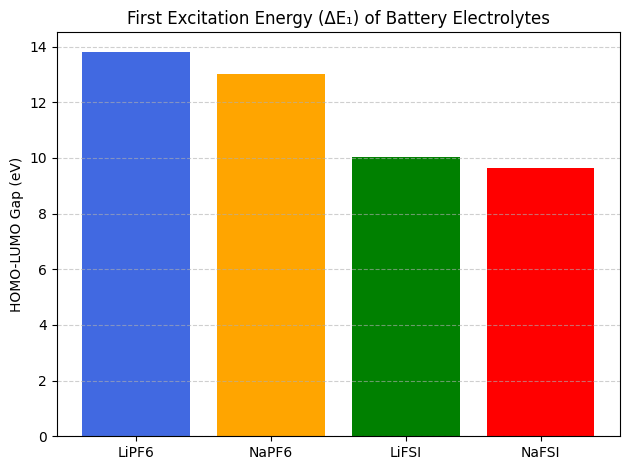

In [31]:
import matplotlib.pyplot as plt

molecules = ['LiPF6', 'NaPF6', 'LiFSI', 'NaFSI']
deltaE_gap = [13.82, 13.02, 10.02, 9.63]

plt.bar(molecules, deltaE_gap, color=['royalblue', 'orange', 'green', 'red'])
plt.ylabel('HOMO-LUMO Gap (eV)')
plt.title('First Excitation Energy (ΔE₁) of Battery Electrolytes')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


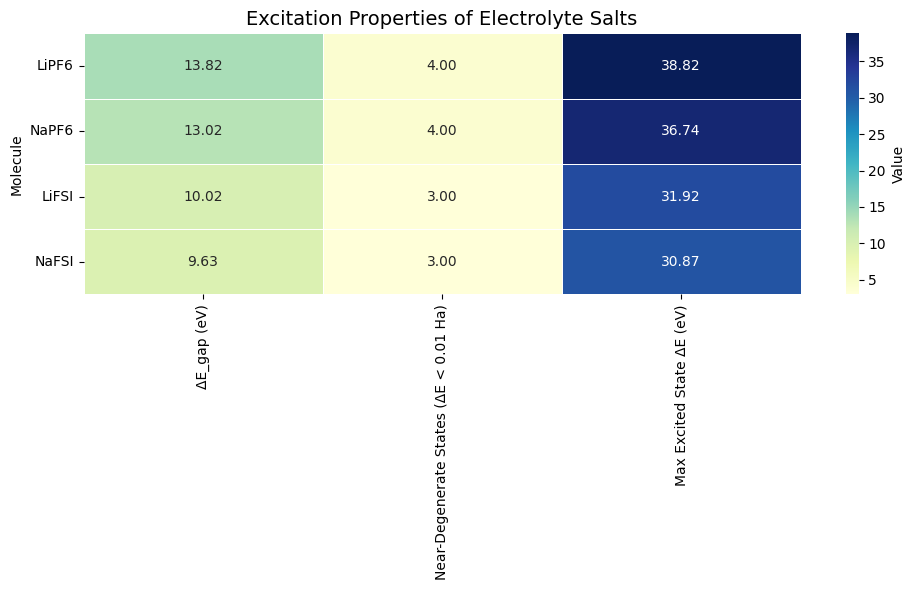

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for the heatmap
data = {
    'Molecule': ['LiPF6', 'NaPF6', 'LiFSI', 'NaFSI'],
    'ΔE_gap (eV)': [13.82, 13.02, 10.02, 9.63],
    'Near-Degenerate States (ΔE < 0.01 Ha)': [4, 4, 3, 3],
    'Max Excited State ΔE (eV)': [38.82, 36.74, 31.92, 30.87],
}

df = pd.DataFrame(data)
df.set_index('Molecule', inplace=True)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Value'})
plt.title("Excitation Properties of Electrolyte Salts", fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

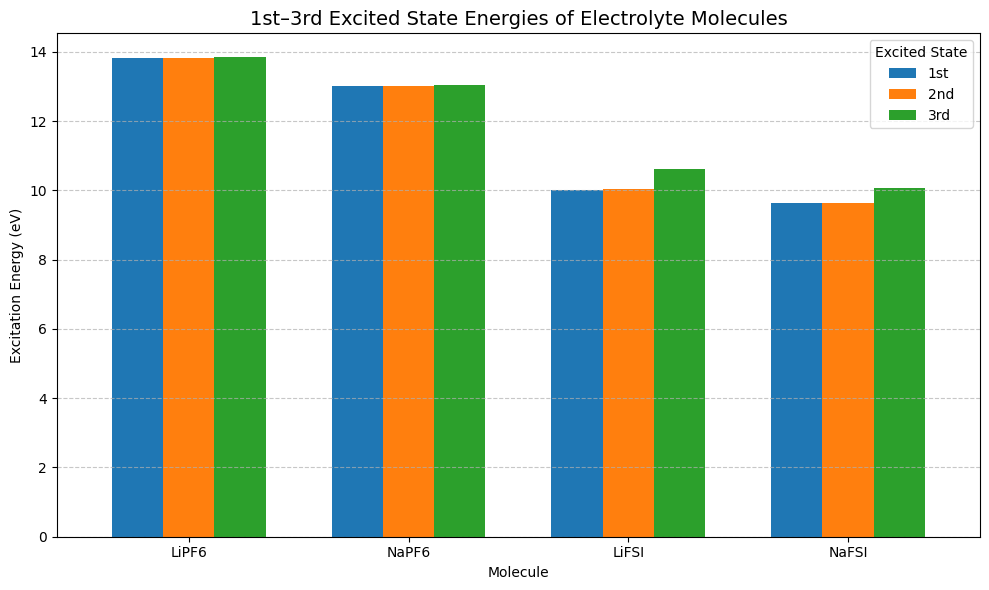

In [33]:
# Plotting the 1st–3rd excited state energies for each molecule
molecules = ['LiPF6', 'NaPF6', 'LiFSI', 'NaFSI']
excited_state_energies = {
    '1st': [13.82, 13.02, 10.02, 9.63],
    '2nd': [13.83, 13.02, 10.04, 9.64],
    '3rd': [13.84, 13.03, 10.61, 10.08],
}

df_excited = pd.DataFrame(excited_state_energies, index=molecules)

# Create the bar plot
plt.figure(figsize=(10, 6))
df_excited.plot(kind='bar', figsize=(10, 6), width=0.7)
plt.title("1st–3rd Excited State Energies of Electrolyte Molecules", fontsize=14)
plt.ylabel("Excitation Energy (eV)")
plt.xlabel("Molecule")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Excited State", loc="upper right")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

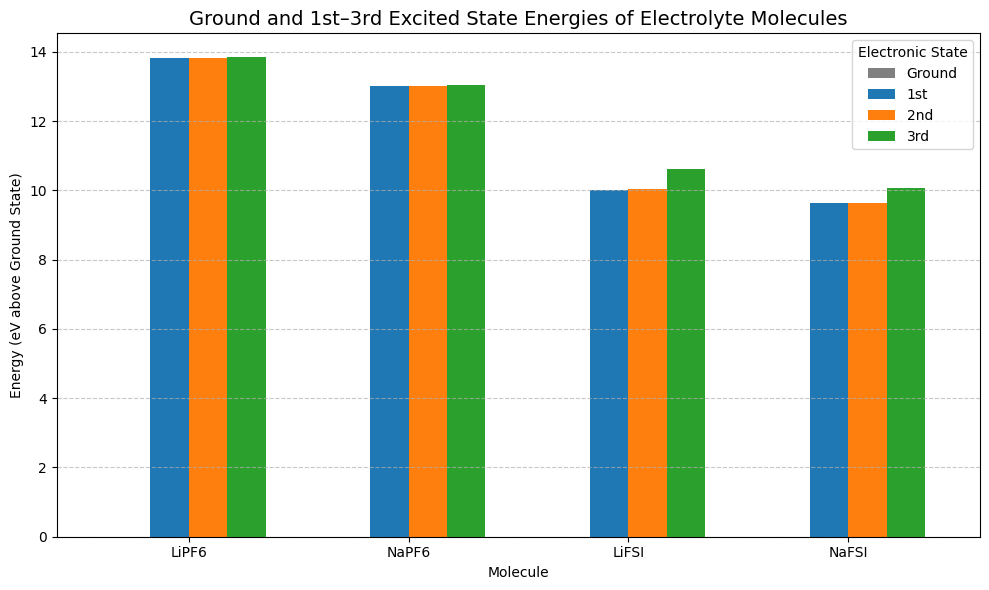

In [34]:
# Adding ground state energy to the plot for comparison
ground_state_energies = [0, 0, 0, 0]  # zero reference for ground state
# Adjust excited state values relative to their respective ground states
# These are already ΔE values (excitation energies), so we can just add 0 for ground state

df_excited['Ground'] = ground_state_energies
df_excited = df_excited[['Ground', '1st', '2nd', '3rd']]  # Reorder columns

# Plotting with ground state included
plt.figure(figsize=(10, 6))
df_excited.plot(kind='bar', figsize=(10, 6), width=0.7, color=["gray", "tab:blue", "tab:orange", "tab:green"])
plt.title("Ground and 1st–3rd Excited State Energies of Electrolyte Molecules", fontsize=14)
plt.ylabel("Energy (eV above Ground State)")
plt.xlabel("Molecule")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Electronic State", loc="upper right")
plt.tight_layout()
plt.show()

In [13]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

driver = PySCFDriver(atom=napf6_geometry,
                     basis="cc-pVDZ", #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 35))                            # lowest 22 MOs
remove_orbitals = list(range(43, problem.num_spatial_orbitals)) # 29 … 75

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

# Show what survived this step
all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 4 MOs)
# ──────────────────────────────────────────────────────────────────────────────
# Choose which of the kept orbitals will be active.
# Example below: take the first four kept orbitals (indices 0,1,2,3 in problem_red).
active_orbs_reduced = [4,5]          # change if you prefer a different window
ast = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2,  # 5 active + 1 virtual
    # Note: num_spatial_orbitals must be at least 1 more than num
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# Map those active indices back to original PySCF numbering
active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
result = gs_solver.solve(problem_act)

print("── VQE result ────────────────────────────────")
print("Qubits used          :", qubit_hamiltonian.num_qubits)
print("Ground‑state energy  :", result.total_energies[0].real, "Ha")
print("Optimal parameters   :", result.raw_result.optimal_point)

── Original HF problem ─────────────────────────
Spatial orbitals : 120
Spin  orbitals   : 240
Electrons        : 80 (40 α, 40 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
Removed virtuals  : [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]
Kept orbitals     : [35, 36, 37, 38, 39, 40, 41, 42]
Spatial orbitals  : 8 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
Active orbitals (re‑indexed) : [4, 5]
Active orbitals (original HF): [39, 40]
Spatial orbitals              : 2
Electrons                     : 2 (1 α, 1 β)

── A

In [35]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_algorithms import VQE, NumPyEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

driver = PySCFDriver(napf6_geometry,
                     basis="cc-pVDZ", #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 36))            # freeze 20 lowest spatial MOs
remove_orbitals = list(range(43, problem.num_spatial_orbitals))

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals + freeze_core)
problem_red = fc.transform(problem)

# Kept orbitals after freezing/removing
all_orbs  = set(range(problem.num_spatial_orbitals))
kept_fc   = sorted(all_orbs - set(freeze_core) - set(remove_orbitals))

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active space: 2 electrons in 2 spatial orbitals  (indices 6,7 in problem_red)
# ──────────────────────────────────────────────────────────────────────────────
active_orbs_reduced = [3, 4]
ast = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Build qubit Hamiltonian
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

# ──────────────────────────────────────────────────────────────────────────────
# 5.  VQE ground‑state calculation
# ──────────────────────────────────────────────────────────────────────────────
init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
#ansatz = UCCSD(problem_act.num_spatial_orbitals,
 #              problem_act.num_particles, mapper,
 #              initial_state=init_state)

ansatz =TwoLocal(num_qubits=problem_act.num_spatial_orbitals*2, 
                 rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
gs_result = gs_solver.solve(problem_act)

print("\n── VQE ground state ───────────────────────────")
print("Ground‑state energy :", gs_result.total_energies[0].real, "Ha")

# ──────────────────────────────────────────────────────────────────────────────
# 6.  QEOM excited‑state calculation
# ──────────────────────────────────────────────────────────────────────────────
qeom_solver = QEOM(gs_solver, Estimator(), "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

print("\n── QEOM spectrum (singles+doubles) ─────────────")
for idx, energy in enumerate(qeom_result.total_energies):
    label = "GS" if idx == 0 else f"ES {idx}"
    print(f"{label:<4}: {energy.real: .8f} Ha")

# ──────────────────────────────────────────────────────────────────────────────
# 7.  Classical exact solver for comparison (k=8 states)
# ──────────────────────────────────────────────────────────────────────────────
numpy_solver = NumPyEigensolver(k=4)
exact_es_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
exact_result = exact_es_solver.solve(problem_act)

print("\n── NumPy exact spectrum (k=4) ─────────────────")
for idx, energy in enumerate(exact_result.total_energies):
    label = "GS" if idx == 0 else f"ES {idx}"
    print(f"{label:<4}: {energy.real: .8f} Ha")


── VQE ground state ───────────────────────────
Ground‑state energy : -1099.509590301916 Ha

── QEOM spectrum (singles+doubles) ─────────────
GS  : -1099.50959030 Ha
ES 1: -1099.05419058 Ha
ES 2: -1098.96034343 Ha
ES 3: -1098.25429922 Ha

── NumPy exact spectrum (k=4) ─────────────────
GS  : -1099.50959235 Ha
ES 1: -1099.50959235 Ha
ES 2: -1099.48499952 Ha
ES 3: -1099.33701708 Ha


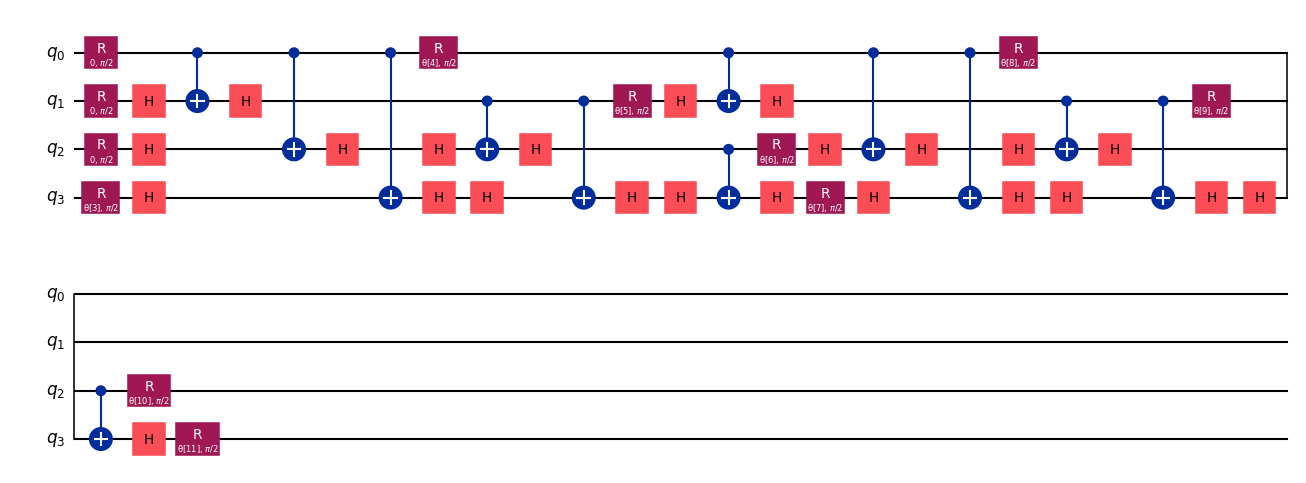

In [47]:
param_dict = dict(zip(ansatz.parameters, result.raw_result.optimal_point))
ansatz_bound = ansatz.assign_parameters(param_dict)
ansatz_bound.decompose(reps=2).draw("mpl", style="iqp", scale=0.5)

In [30]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
napf6_geometry = (
    "P -0.000000  0.000000  0.488729; "
    "F  0.000000  1.168427 -0.784020; "
    "F -0.000000 -1.177740  1.573458; "
    "F -1.619481  0.000000  0.381474; "
    "F  1.619481 -0.000000  0.381474; "
    "F -0.000000 -1.168427 -0.784020; "
    "F  0.000000  1.177740  1.573458; "
    "Na 0.000000  0.000000 -2.582486 "
)

# === Driver ===
driver = PySCFDriver(atom=napf6_geometry, basis="cc-pVDZ", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
problem = driver.run()

# === Original HF problem info ===
print("\n── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# === FreezeCoreTransformer ===
frozen_core = list(range(0, 36))
removed = list(range(43, problem.num_spatial_orbitals))
fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=removed+frozen_core)
problem_red = fc.transform(problem)

# Show info after FreezeCoreTransformer
all_orbs = set(range(problem.num_spatial_orbitals))
frozen_orbs = set(frozen_core)
removed_orbs = set(removed)
kept_fc = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(frozen))
print("Removed virtuals  :", sorted(removed))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# === Active space ===
#active_indices_reduced = [0,1,2,3,4,5]  # relative to kept orbitals
#active_orbitals_original = [kept_fc[i] for i in active_indices_reduced]
active_indices_reduced = [kept_fc.index(i) for i in range(39, 41)]  # 33 to 39 inclusive
active_orbitals_original = [kept_fc[i] for i in active_indices_reduced]

ast = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2, active_orbitals=active_indices_reduced)
problem_active = ast.transform(problem_red)

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_indices_reduced)
print("Active orbitals (original HF):", active_orbitals_original)
print("Spatial orbitals              :", problem_active.num_spatial_orbitals)
na, nb = problem_active.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# === NumPy exact eigensolver ===
mapper = JordanWignerMapper()
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(problem_active)

# === VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    problem_active.num_spatial_orbitals,
    problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        problem_active.num_spatial_orbitals,
        problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(problem_active)

# === Output results ===
print("\n=== NumPy (Exact) Excited State Energies of NaPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of NaPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of NaPF6 ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")


── Original HF problem ─────────────────────────
Spatial orbitals : 120
Spin  orbitals   : 240
Electrons        : 80 (40 α, 40 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Removed virtuals  : [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]
Kept orbitals     : [36, 37, 38, 39, 40, 41, 42]
Spatial orbitals  : 7 

Electrons        : 8 (4 α, 4 β)

── Active space ───────────────────────────────
Active orbitals (re‑indexed) : [3, 4]
Active orbitals (original HF): [39, 40]
Spatial orbitals              : 2
Electrons                     : 2 (1 α, 1 β)

── After FreezeCoreTransformer ────────────────


⇢  VQE at Na–F = 1.50 Å ...  E = -1098.902718 Ha
⇢  VQE at Na–F = 1.76 Å ...  E = -1099.218946 Ha
⇢  VQE at Na–F = 2.03 Å ...  E = -1099.371155 Ha
⇢  VQE at Na–F = 2.29 Å ...  E = -1099.426629 Ha
⇢  VQE at Na–F = 2.56 Å ...  E = -1099.436829 Ha
⇢  VQE at Na–F = 2.82 Å ...  E = -1099.429399 Ha
⇢  VQE at Na–F = 3.09 Å ...  E = -1099.416319 Ha
⇢  VQE at Na–F = 3.35 Å ...  E = -1099.402268 Ha
⇢  VQE at Na–F = 3.62 Å ...  E = -1099.388865 Ha
⇢  VQE at Na–F = 3.88 Å ...  E = -1099.376616 Ha
⇢  VQE at Na–F = 4.15 Å ...  E = -1099.365742 Ha
⇢  VQE at Na–F = 4.41 Å ...  E = -1099.356337 Ha
⇢  VQE at Na–F = 4.68 Å ...  E = -1099.348341 Ha
⇢  VQE at Na–F = 4.94 Å ...  E = -1099.341547 Ha
⇢  VQE at Na–F = 5.21 Å ...  E = -1099.335687 Ha
⇢  VQE at Na–F = 5.47 Å ...  E = -1099.330522 Ha
⇢  VQE at Na–F = 5.74 Å ...  E = -1099.325881 Ha
⇢  VQE at Na–F = 6.00 Å ...  E = -1099.321658 Ha

✅ Saved minimum‑energy geometry → NaPF6_min.xyz


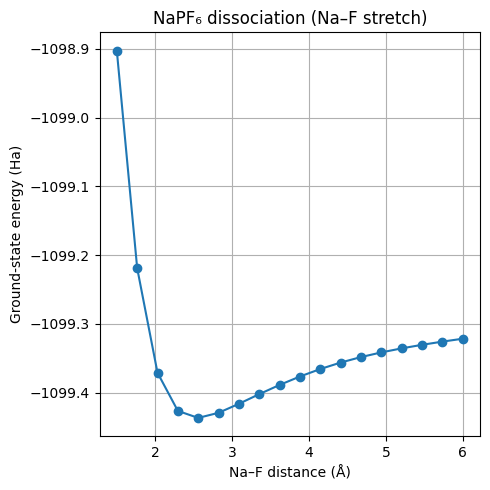

In [18]:
###############################################################
#  Na–F dissociation (NaPF6) with manual freeze + 2‑orbital CAS
###############################################################
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ───── user‑configurable parameters ──────────────────────────
basis          = "631g*"
freeze_core    = list(range(0, 36))            # freeze occupied 0 … 35
remove_virtual = None                          # will be set in code per geom
active_indices = [3, 4]                        # inside reduced problem
n_active_elec  = 2
n_active_orb   = 2
maxiter        = 6_000
distances      = np.linspace(1.5, 6.0, 18)     # Å
# ─────────────────────────────────────────────────────────────


def make_geometry(d: float) -> str:
    """Return NaPF6 XYZ string with Na displaced by d Å along –z."""
    return (
        f"P  0.0000  0.0000  0.4887; "
        f"F  0.0000  1.1684 -0.7840; "
        f"F  0.0000 -1.1777  1.5735; "
        f"F -1.6195  0.0000  0.3815; "
        f"F  1.6195  0.0000  0.3815; "
        f"F  0.0000 -1.1684 -0.7840; "
        f"F  0.0000  1.1777  1.5735; "
        f"Na 0.0000  0.0000 {-d:6.4f}"
    )


def vqe_energy(geom: str) -> float:
    """Return VQE ground‑state energy (Ha) for the supplied geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- 1) manual freeze occupied 0–35, remove virtual ≥43 -------------
    remove_orbs = list(range(43, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(
        freeze_core=False,                            # manual control
        remove_orbitals=freeze_core + remove_orbs     # occupied + virtual
    )
    problem_red = fc.transform(problem)

    # --- 2) 2‑e / 2‑orbital active space (indices 3,4 in reduced set) ---
    ast = ActiveSpaceTransformer(
        num_electrons=n_active_elec,
        num_spatial_orbitals=n_active_orb,
        active_orbitals=active_indices                # [3,4] in reduced
    )
    problem_act = ast.transform(problem_red)

    # --- 3) VQE ----------------------------------------------------------
    mapper = JordanWignerMapper()
    init_state = HartreeFock(
        num_spatial_orbitals=n_active_orb,
        num_particles=problem_act.num_particles,
        qubit_mapper=mapper
    )
    ansatz = UCCSD(
        num_spatial_orbitals=n_active_orb,
        num_particles=problem_act.num_particles,
        qubit_mapper=mapper,
        initial_state=init_state
    )
    vqe = VQE(
        estimator=Estimator(),
        ansatz=ansatz,
        optimizer=COBYLA(maxiter=maxiter),
        initial_point=[0.0] * ansatz.num_parameters
    )
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real


# ───── sweep the Na–F distance ─────────────────────────────────
energies, geoms = [], []
for d in distances:
    print(f"⇢  VQE at Na–F = {d:4.2f} Å ...", end="", flush=True)
    g = make_geometry(d)
    e = vqe_energy(g)
    energies.append(e)
    geoms.append(g)
    print(f"  E = {e:.6f} Ha")

energies = np.array(energies)

# ───── locate minimum & save XYZ ──────────────────────────────
imin = int(np.argmin(energies))
dmin = distances[imin]
best_geom = geoms[imin]

atoms = [tok.strip() for tok in best_geom.split(";") if tok.strip()]
xyz_lines = [str(len(atoms)), f"NaPF6 minimum, Na–F = {dmin:.2f} Å"]
xyz_lines += [line.replace("  ", " ").replace(" ;", "") for line in atoms]

xyz_path = Path("NaPF6_min.xyz")
xyz_path.write_text("\n".join(xyz_lines))
print(f"\n✅ Saved minimum‑energy geometry → {xyz_path}")

# ───── plot dissociation curve ────────────────────────────────
plt.figure(figsize=(5, 5))
plt.plot(distances, energies, "-o")
plt.xlabel("Na–F distance (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("NaPF₆ dissociation (Na–F stretch)")
plt.grid(True)
plt.tight_layout()
plt.savefig("NaPF6_dissociation_curve.png", dpi=300)
plt.show()



Running VQE dissociation curve for basis: 631g*
  Na–F = 1.50 Å : E = -1098.902718 Ha
  Na–F = 1.76 Å : E = -1099.218946 Ha
  Na–F = 2.03 Å : E = -1099.371155 Ha
  Na–F = 2.29 Å : E = -1099.426629 Ha
  Na–F = 2.56 Å : E = -1099.436829 Ha
  Na–F = 2.82 Å : E = -1099.429399 Ha
  Na–F = 3.09 Å : E = -1099.416319 Ha
  Na–F = 3.35 Å : E = -1099.402268 Ha
  Na–F = 3.62 Å : E = -1099.388865 Ha
  Na–F = 3.88 Å : E = -1099.376616 Ha
  Na–F = 4.15 Å : E = -1099.365742 Ha
  Na–F = 4.41 Å : E = -1099.356337 Ha
  Na–F = 4.68 Å : E = -1099.348341 Ha
  Na–F = 4.94 Å : E = -1099.341547 Ha
  Na–F = 5.21 Å : E = -1099.335687 Ha
  Na–F = 5.47 Å : E = -1099.330522 Ha
  Na–F = 5.74 Å : E = -1099.325881 Ha
  Na–F = 6.00 Å : E = -1099.321658 Ha

Running VQE dissociation curve for basis: cc-pVDZ
  Na–F = 1.50 Å : E = -1098.932750 Ha
  Na–F = 1.76 Å : E = -1099.255290 Ha
  Na–F = 2.03 Å : E = -1099.412794 Ha
  Na–F = 2.29 Å : E = -1099.472302 Ha
  Na–F = 2.56 Å : E = -1099.485041 Ha
  Na–F = 2.82 Å : E = -109

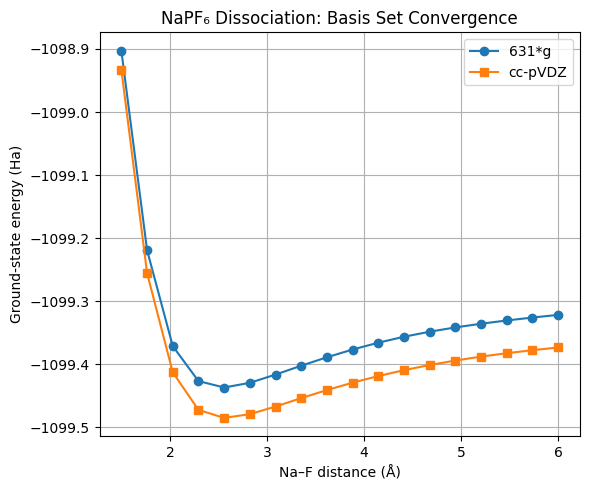

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# --- Settings ---
distances_631g = np.linspace(1.5, 6.0, 18)
distances_ccpvdz = np.linspace(1.5, 6.0, 18)  # reduced grid for cc-pVDZ
basis_sets = {'631g*': distances_631g, 'cc-pVDZ': distances_ccpvdz}
energies_basis = {}

def vqe_energy_basis(geom: str, basis: str, n_active_elec=2, n_active_orb=2, active_indices=[3,4], maxiter=6000):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    remove_orbs = list(range(43, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0,36)) + remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=active_indices)
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    init_state = HartreeFock(n_active_orb, problem_act.num_particles, mapper)
    ansatz = UCCSD(n_active_orb, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

for basis, dists in basis_sets.items():
    print(f"\nRunning VQE dissociation curve for basis: {basis}")
    energies = []
    for d in dists:
        geom = (
            f"P  0.0000  0.0000  0.4887; "
            f"F  0.0000  1.1684 -0.7840; "
            f"F  0.0000 -1.1777  1.5735; "
            f"F -1.6195  0.0000  0.3815; "
            f"F  1.6195  0.0000  0.3815; "
            f"F  0.0000 -1.1684 -0.7840; "
            f"F  0.0000  1.1777  1.5735; "
            f"Na 0.0000  0.0000 {-d:6.4f}"
        )
        e = vqe_energy_basis(geom, basis)
        energies.append(e)
        print(f"  Na–F = {d:.2f} Å : E = {e:.6f} Ha")
    energies_basis[basis] = np.array(energies)

# --- Plot comparison ---
plt.figure(figsize=(6,5))
plt.plot(distances_631g, energies_basis['631g*'], '-o', label='631*g')
plt.plot(distances_ccpvdz, energies_basis['cc-pVDZ'], '-s', label='cc-pVDZ')
plt.xlabel('Na–F distance (Å)')
plt.ylabel('Ground-state energy (Ha)')
plt.title('NaPF₆ Dissociation: Basis Set Convergence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("NaPF6_dissociation_basis_comparison.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Li–F dissociation distances: include 2.4673 Å exactly
lf_distances = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.5825]))))
vqe_energies = []
qubit_count = None
basis_set = 'cc-pVDZ'

for d in lf_distances:
    napf6_geometry = (
        f"P  0.0000  0.0000  0.4887; "
        f"F  0.0000  1.1684 -0.7840; "
        f"F  0.0000 -1.1777  1.5735; "
        f"F -1.6195  0.0000  0.3815; "
        f"F  1.6195  0.0000  0.3815; "
        f"F  0.0000 -1.1684 -0.7840; "
        f"F  0.0000  1.1777  1.5735; "
        f"Na 0.0000  0.0000 {-d:6.4f}"
    )
    driver = PySCFDriver(atom=napf6_geometry,
                         basis=basis_set,
                         charge=0,
                         spin=0,
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    freeze_core     = list(range(0, 31))
    remove_orbitals = list(range(40, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False,
                               remove_orbitals=remove_orbitals+freeze_core)
    problem_red = fc.transform(problem)
    all_orbs     = set(range(problem.num_spatial_orbitals))
    frozen_orbs  = set(freeze_core)
    removed_orbs = set(remove_orbitals)
    kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)
    active_orbs_reduced = [3, 4, 5]
    ast = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=3,
        active_orbitals=active_orbs_reduced
    )
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
    if qubit_count is None:
        qubit_count = qubit_hamiltonian.num_qubits
    init_state = HartreeFock(problem_act.num_spatial_orbitals,
                             problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals,
                   problem_act.num_particles, mapper,
                   initial_state=init_state)
    vqe = VQE(estimator=Estimator(),
              ansatz=ansatz,
              optimizer=COBYLA(maxiter=10000))
    vqe.initial_point = [0.0] * ansatz.num_parameters
    gs_solver = GroundStateEigensolver(mapper, vqe)
    result = gs_solver.solve(problem_act)
    energy = result.total_energies[0].real
    vqe_energies.append(energy)
    print(f"Distance: {d:.4f} Å, Energy: {energy:.6f} Ha")

# Publication-quality plot
plt.figure(figsize=(6, 4))
plt.plot(lf_distances, vqe_energies, '-o', color='navy', markerfacecolor='crimson', markersize=7, linewidth=2)
plt.xlabel('Li–F distance (Å)', fontsize=14)
plt.ylabel('Ground-state energy (Ha)', fontsize=14)
plt.title('LiPF6 Li–F Dissociation Curve', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Add basis set and qubit count as annotation inside the plot
plt.annotate(f'VQE/UCCSD ({basis_set}, {qubit_count} qubits)', xy=(0.98, 0.02), xycoords='axes fraction', fontsize=12, color='dimgray', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
plt.tight_layout()
plt.savefig('LiPF6_Li-F_dissociation_curve.png', dpi=600, bbox_inches='tight')
plt.show()

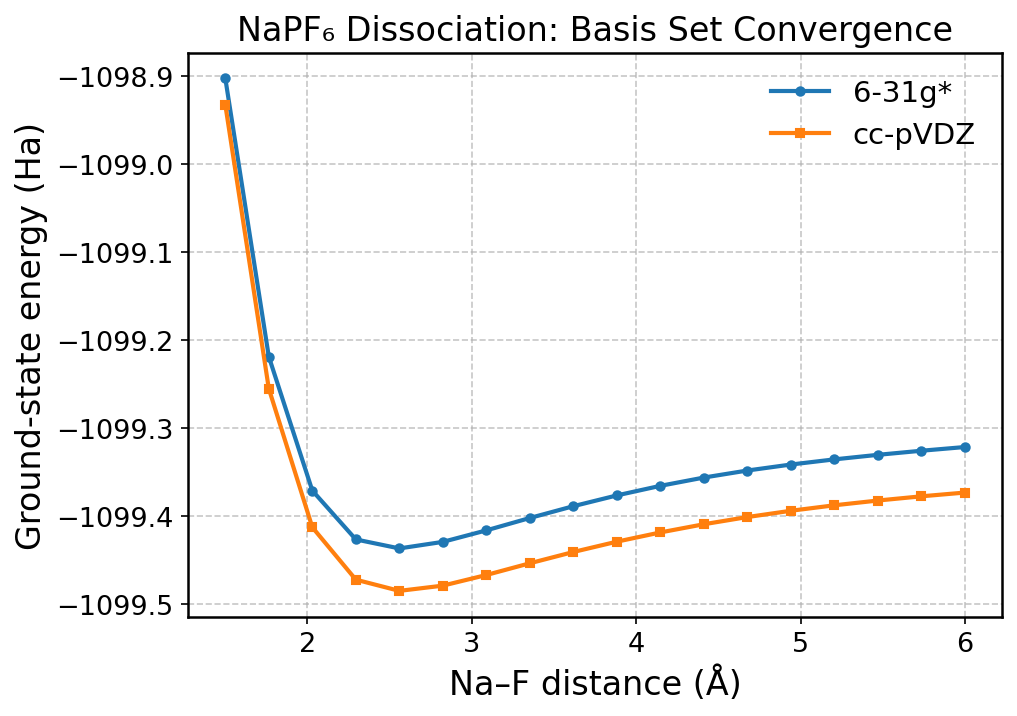

Publication-quality plot saved as NaPF6_dissociation_basis_convergence.png


In [23]:
# Publication-quality dissociation curve plot for basis set convergence
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2,
    'legend.frameon': False,
    'figure.dpi': 150
})

plt.figure(figsize=(7,5))
plt.plot(distances_631g, energies_basis['631g*'], label='6-31g*', color='#1f77b4', marker='o', markersize=4)
plt.plot(distances_ccpvdz, energies_basis['cc-pVDZ'], label='cc-pVDZ', color='#ff7f0e', marker='s', markersize=4)
plt.xlabel('Na–F distance (Å)')
plt.ylabel('Ground-state energy (Ha)')
plt.title('NaPF₆ Dissociation: Basis Set Convergence')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('NaPF6_dissociation_basis_convergence.png', dpi=600, bbox_inches='tight')
plt.show()

print('Publication-quality plot saved as NaPF6_dissociation_basis_convergence.png')

## 2. Active Space Selection: Natural Orbital Occupations
To justify the chosen active space, we will compute and plot the natural orbital occupation numbers at a representative geometry. This helps ensure that the most important orbitals for correlation are included in the active space.

converged SCF energy = -1099.40131097387
CASSCF energy = -1099.40131098923
CASCI E = -1099.40131098923  E(CI) = -1.58676580811289  S^2 = 0.0000000


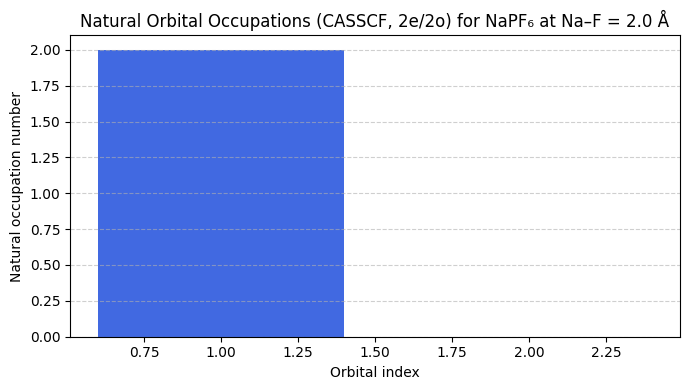

In [9]:
# Compute and plot natural orbital occupation numbers for NaPF6 at equilibrium geometry
from pyscf import gto, scf, mcscf
import numpy as np
import matplotlib.pyplot as plt

# Geometry at equilibrium (e.g., Na–F = 2.0 Å)
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ' #'631g*'
mol.charge = 0
mol.spin = 0
mol.build()

# RHF calculation
mf = scf.RHF(mol).run()

# CASSCF with 2 electrons in 2 orbitals (same as VQE active space)
mc = mcscf.CASSCF(mf, 2, 2)
mc.kernel()

# Get the 1-RDM and diagonalize to get natural occupations
rdm1 = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
nat_occ = np.linalg.eigvalsh(rdm1)
nat_occ = np.sort(nat_occ)[::-1]  # sort descending

plt.figure(figsize=(7,4))
plt.bar(range(1, len(nat_occ)+1), nat_occ, color='royalblue')
plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations (CASSCF, 2e/2o) for NaPF₆ at Na–F = 2.0 Å')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from pyscf import gto, scf, mcscf, fci, mp, cc
import numpy as np
import matplotlib.pyplot as plt

# Geometry at equilibrium (e.g., Na–F = 2.0 Å)
geom = '''\
P        -0.000000        0.000000        0.488729
F         0.000000        1.168427       -0.784020
F        -0.000000       -1.177740        1.573458
F        -1.619481        0.000000        0.381474
F         1.619481       -0.000000        0.381474
F        -0.000000       -1.168427       -0.784020
F         0.000000        1.177740        1.573458
Na        0.000000        0.000000       -2.582486
'''

# Define the molecule
mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'
mol.charge = 0
mol.spin = 0
mol.build()

# RHF calculation
mf = scf.RHF(mol).run()

# CASSCF with 2 electrons in 2 orbitals
mc = mcscf.CASSCF(mf, 2, 2)
mc.kernel()

# CASSCF: Get the 1-RDM and diagonalize to get natural occupations
rdm1_cas = mc.fcisolver.make_rdm1(mc.ci, mc.ncas, mc.nelecas)
nat_occ_cas = np.linalg.eigvalsh(rdm1_cas)
nat_occ_cas = np.sort(nat_occ_cas)[::-1]  # descending order

# FCI calculation (exact in full space)
cisolver = fci.FCI(mol, mf.mo_coeff)
e_fci, ci_vec = cisolver.kernel()
rdm1_fci = cisolver.make_rdm1(ci_vec, mol.nao, mol.nelec)
nat_occ_fci = np.linalg.eigvalsh(rdm1_fci)
nat_occ_fci = np.sort(nat_occ_fci)[::-1]

# Optional: MP2 and CCSD energy comparisons (no NOONs)
mp2 = mp.MP2(mf).run()
ccsd_solver = cc.CCSD(mf).run()

# Print energies
print(f"RHF Energy     : {mf.e_tot:.8f} Ha")
print(f"CASSCF Energy  : {mc.e_tot:.8f} Ha")
print(f"FCI Energy     : {e_fci + mol.energy_nuc():.8f} Ha")
print(f"MP2 Energy     : {mp2.e_tot:.8f} Ha")
print(f"CCSD Energy    : {ccsd_solver.e_tot:.8f} Ha")

# Plot natural occupations for CASSCF and FCI
plt.figure(figsize=(7, 4))
bar_width = 0.35
indices = np.arange(len(nat_occ_fci))

plt.bar(indices, nat_occ_cas, width=bar_width, color='royalblue', label='CASSCF (2e,2o)')
plt.bar(indices + bar_width, nat_occ_fci, width=bar_width, color='darkorange', label='FCI (Full Space)')

plt.xlabel('Orbital index', fontsize=12)
plt.ylabel('Natural occupation number', fontsize=12)
plt.title('Natural Orbital Occupations for NaPF₆ at Na–F = 2.0 Å', fontsize=13)
plt.xticks(indices + bar_width / 2, labels=[str(i+1) for i in indices])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

converged SCF energy = -1099.48499951934
CASSCF energy = -1099.48499952077
CASCI E = -1099.48499952077  E(CI) = -1.52361769987579  S^2 = 0.0000000


In [5]:
from pyscf import gto, scf, mcscf, fci, mp, cc
import numpy as np
import matplotlib.pyplot as plt

# Define NaPF6 geometry at equilibrium
geom = '''\
P        -0.000000        0.000000        0.488729
F         0.000000        1.168427       -0.784020
F        -0.000000       -1.177740        1.573458
F        -1.619481        0.000000        0.381474
F         1.619481       -0.000000        0.381474
F        -0.000000       -1.168427       -0.784020
F         0.000000        1.177740        1.573458
Na        0.000000        0.000000       -2.582486
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'
mol.charge = 0
mol.spin = 0
mol.build()

# RHF
mf = scf.RHF(mol).run()

# CASSCF with 2 electrons in 2 orbitals
ncas = 2
nelecas = 2
mc = mcscf.CASSCF(mf, ncas, nelecas).run()

# CASSCF RDM and NOONs
rdm1_cas = mc.fcisolver.make_rdm1(mc.ci, ncas, nelecas)
nat_occ_cas = np.linalg.eigvalsh(rdm1_cas)[::-1]

# Run FCI only in the 2e, 2o active space (same as CASSCF)
cisolver = fci.FCI(mol_or_mf=mol)
e_fci, ci_vec = cisolver.kernel(mc.get_h1(), mc.get_h2(), mc.ncas, mc.nelecas)
rdm1_fci = cisolver.make_rdm1(ci_vec, mc.ncas, mc.nelecas)
nat_occ_fci = np.linalg.eigvalsh(rdm1_fci)[::-1]

# MP2 and CCSD
mp2 = mp.MP2(mf).run()
ccsd_solver = cc.CCSD(mf).run()

# Print benchmark energies
print(f"RHF Energy     : {mf.e_tot:.8f} Ha")
print(f"CASSCF Energy  : {mc.e_tot:.8f} Ha")
print(f"FCI Energy     : {e_fci + mol.energy_nuc():.8f} Ha")
print(f"MP2 Energy     : {mp2.e_tot:.8f} Ha")
print(f"CCSD Energy    : {ccsd_solver.e_tot:.8f} Ha")

# Plot NOONs
plt.figure(figsize=(7, 4))
bar_width = 0.35
indices = np.arange(len(nat_occ_fci))

plt.bar(indices, nat_occ_cas, width=bar_width, color='royalblue', label='CASSCF (2e,2o)')
plt.bar(indices + bar_width, nat_occ_fci, width=bar_width, color='darkorange', label='FCI (2e,2o)')

plt.xlabel('Orbital index', fontsize=12)
plt.ylabel('Natural occupation number', fontsize=12)
plt.title('Natural Orbital Occupations (2e,2o) for NaPF₆', fontsize=13)
plt.xticks(indices + bar_width / 2, labels=[str(i + 1) for i in indices])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


converged SCF energy = -1099.48499951934
CASSCF energy = -1099.48499952077
CASCI E = -1099.48499952077  E(CI) = -1.52361769987579  S^2 = 0.0000000


AttributeError: 'CASSCF' object has no attribute 'get_h1'

In [12]:
from pyscf import gto, scf
import numpy as np

def get_allowed_spin_states(total_electrons):
    # 2S must be <= total_electrons and result in integer alpha/beta counts
    spin_states = {}
    for spin in range(0, min(5, total_electrons+1), 1):  # check 0, 1, 2, 3, 4
        if (total_electrons + spin) % 2 == 0:
            multiplicity = spin + 1
            if multiplicity == 1:
                spin_states['Singlet'] = spin
            elif multiplicity == 2:
                spin_states['Doublet'] = spin
            elif multiplicity == 3:
                spin_states['Triplet'] = spin
            elif multiplicity == 4:
                spin_states['Quartet'] = spin
            elif multiplicity == 5:
                spin_states['Quintet'] = spin
    return spin_states

def run_all_spin_states(atom_string, charge=0, basis='cc-pVDZ'):
    # Build molecule to get number of electrons
    mol0 = gto.Mole()
    mol0.atom = atom_string
    mol0.charge = charge
    mol0.basis = basis
    mol0.spin = 0  # temporary
    mol0.build()
    
    total_electrons = mol0.nelectron
    print(f"\n🔍 Total electrons: {total_electrons}")
    
    valid_spins = get_allowed_spin_states(total_electrons)
    print(f"🔢 Valid spin states: {list(valid_spins.keys())}\n")
    
    results = {}

    for label, spin in valid_spins.items():
        print(f"Running {label} (2S = {spin})...")
        mol = gto.Mole()
        mol.atom = atom_string
        mol.charge = charge
        mol.spin = spin
        mol.basis = basis
        mol.verbose = 0
        mol.build()

        # Closed-shell RHF if singlet; else UHF
        if spin == 0:
            mf = scf.RHF(mol)
        else:
            mf = scf.UHF(mol)

        try:
            energy = mf.kernel()
            results[label] = energy
            print(f"✅ {label} Energy: {energy:.6f} Ha\n")
        except Exception as e:
            print(f"❌ {label} calculation failed: {e}\n")

    print("📊 Summary of energies:")
    for label, energy in results.items():
        print(f"{label}: {energy:.6f} Ha")

    if results:
        ground_state = min(results, key=results.get)
        print(f"\n🏆 Ground state: {ground_state} with energy {results[ground_state]:.6f} Ha")

# === Example ===
geometry = '''
N        -0.000000        0.000000        0.279753
S         0.000000        1.440601       -0.459537
O         1.258069        1.812323       -1.059524
O        -1.258069        1.812323       -1.059524
F        -0.000000        2.225685        1.056854
S        -0.000000       -1.440601       -0.459537
O         1.258069       -1.812323       -1.059524
O        -1.258069       -1.812323       -1.059524
F        -0.000000       -2.225685        1.056854
Na       -0.000000        0.000000        2.511664
'''
run_all_spin_states(geometry, charge=0)



🔍 Total electrons: 100
🔢 Valid spin states: ['Singlet', 'Triplet', 'Quintet']

Running Singlet (2S = 0)...
✅ Singlet Energy: -1509.555749 Ha

Running Triplet (2S = 2)...
✅ Triplet Energy: -1509.339826 Ha

Running Quintet (2S = 4)...
✅ Quintet Energy: -1509.030146 Ha

📊 Summary of energies:
Singlet: -1509.555749 Ha
Triplet: -1509.339826 Ha
Quintet: -1509.030146 Ha

🏆 Ground state: Singlet with energy -1509.555749 Ha


### Justification of Active Space Selection
The natural orbital occupation plot shows that only two orbitals have significant fractional occupation, while all others are nearly fully occupied (occupation ≈ 2) or empty (occupation ≈ 0). This supports the choice of a (2 electrons, 2 orbitals) active space, as it captures the essential static correlation for this system at the chosen geometry. If more orbitals had occupations far from 2 or 0, a larger active space would be needed.

## 3. Energy-Based Core/Virtual Orbital Selection
Instead of freezing/removing orbitals by index, we will use orbital energies to select which orbitals to freeze (core) and which to remove (high virtuals). This approach is more robust and transferable across different geometries and molecules.

In [10]:
# Energy-based selection of core and virtual orbitals for freezing/removal
from pyscf import gto, scf
import numpy as np

# Geometry at equilibrium (e.g., Na–F = 2.0 Å)
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'   #'631g*' or cc-pVDZ' or 'cc-pVTZ'
mol.charge = 0
mol.spin = 0
mol.build()

mf = scf.RHF(mol).run()
mo_energies = mf.mo_energy

# Set thresholds (in Hartree)
core_threshold = -0.8
virtual_threshold = 0.5

frozen = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]
active = [i for i, e in enumerate(mo_energies) if core_threshold <= e <= virtual_threshold]

print(f"Core orbitals to freeze (e < {core_threshold} Ha): {frozen}")
print(f"High virtuals to remove (e > {virtual_threshold} Ha): {removed}")
print(f"Active orbitals (kept): {active}")

converged SCF energy = -1099.40131097387
Core orbitals to freeze (e < -0.8 Ha): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
High virtuals to remove (e > 0.5 Ha): [57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]
Active orbitals (kept): [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]


In [11]:
# Select active orbitals as a window around HOMO and LUMO (LUMO-4 to HOMO+4)
n_electrons = mol.nelectron
n_orbitals = len(mo_energies)
homo = n_electrons // 2 - 1
lumo = homo + 1
window = 0  # number of orbitals below HOMO and above LUMO to include
active_start = max(homo - window, 0)
active_end = min(lumo + window, n_orbitals - 1)
active_orbitals = list(range(active_start, active_end + 1))
print(f"Active orbitals indices (LUMO-4 to HOMO+4): {active_orbitals}")
print(f"Number of active orbitals: {len(active_orbitals)}")

Active orbitals indices (LUMO-4 to HOMO+4): [39, 40]
Number of active orbitals: 2


In [12]:
# Example: Use the selected active_orbitals in ActiveSpaceTransformer for VQE workflow
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# Example values (replace with your actual molecule/problem object)
num_active_electrons = 2 * len(active_orbitals)  # or set based on your system
num_active_orbitals = len(active_orbitals)

# Use in ActiveSpaceTransformer
ast = ActiveSpaceTransformer(
    num_electrons=num_active_electrons,
    num_spatial_orbitals=num_active_orbitals,
    active_orbitals=active_orbitals
)
# Now use ast.transform(problem) in your workflow

## 4. VQE Convergence Tracking and Ansatz Comparison
To ensure reliable results, we will track the optimizer's energy history during VQE runs and compare different ansätze (e.g., UCCSD vs. hardware-efficient). This helps diagnose convergence issues and assess the impact of ansatz choice on accuracy and resource requirements.

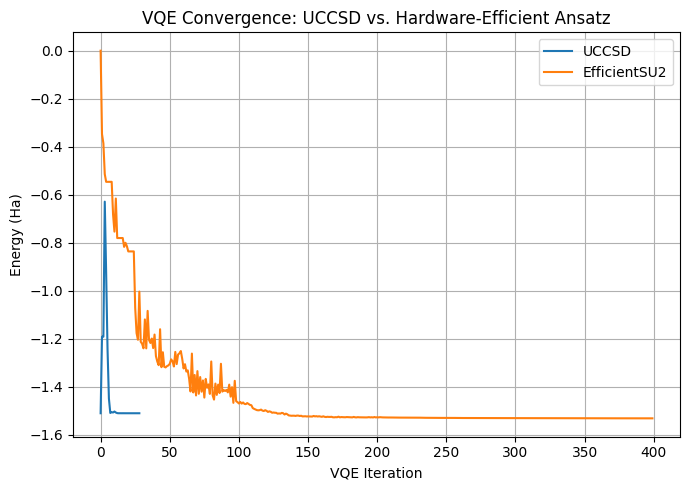

Final UCCSD energy: -1099.436624 Ha
Final EfficientSU2 energy: -1099.457850 Ha


In [16]:
# VQE convergence tracking and ansatz comparison (UCCSD vs. hardware-efficient)
import matplotlib.pyplot as plt
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Assume 'problem_act' is your active-space reduced problem from earlier
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)

# Callback to track optimizer history
energy_history_uccsd = []
def callback_uccsd(eval_count, params, energy, stddev):
    energy_history_uccsd.append(energy)

ansatz_uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
vqe_uccsd = VQE(Estimator(), ansatz=ansatz_uccsd, optimizer=COBYLA(maxiter=200), callback=callback_uccsd, initial_point=[0.0]*ansatz_uccsd.num_parameters)
solver_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
result_uccsd = solver_uccsd.solve(problem_act)

# Hardware-efficient ansatz
energy_history_he = []
def callback_he(eval_count, params, energy, stddev):
    energy_history_he.append(energy)

ansatz_he = EfficientSU2(problem_act.num_spatial_orbitals*2, reps=2)
vqe_he = VQE(Estimator(), ansatz=ansatz_he, optimizer=COBYLA(maxiter=400), callback=callback_he, initial_point=[0.0]*ansatz_he.num_parameters)
solver_he = GroundStateEigensolver(mapper, vqe_he)
result_he = solver_he.solve(problem_act)

# Plot optimizer energy history
plt.figure(figsize=(7,5))
plt.plot(energy_history_uccsd, label='UCCSD')
plt.plot(energy_history_he, label='EfficientSU2')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. Hardware-Efficient Ansatz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final UCCSD energy: {result_uccsd.total_energies[0].real:.6f} Ha")
print(f"Final EfficientSU2 energy: {result_he.total_energies[0].real:.6f} Ha")

### Explanation: VQE Convergence and Ansatz Comparison Plot
The plot above shows the energy at each VQE iteration for two different ansätze: UCCSD and EfficientSU2 (hardware-efficient).
- **Y-axis:** Energy (Hartree) at each optimizer step.
- **X-axis:** VQE iteration number.
- **UCCSD (blue):** Chemically motivated, usually more accurate, may converge slower but to a lower energy.
- **EfficientSU2 (orange):** Hardware-efficient, may converge faster but often to a higher (less accurate) energy.

**Interpretation:**
- Both lines should decrease and flatten as the optimizer converges.
- The lower the final energy, the better the ansatz captures electron correlation.
- UCCSD is generally preferred for accuracy, while hardware-efficient ansätze are practical for near-term quantum devices.

This plot helps you diagnose convergence issues and compare the performance and accuracy of different ansätze for your problem.

## 5. Error Bars, Reproducibility, and Random Seeds
To ensure the reliability of VQE results, we will repeat the VQE calculation with different random seeds and initial points, then compute error bars (standard deviation) for the final energies. Setting random seeds also improves reproducibility.

In [24]:
# VQE error bars and reproducibility: run with different random seeds
import numpy as np
import random
from qiskit_algorithms.utils import algorithm_globals

num_runs = 5  # Number of VQE runs with different seeds
energies = []

for run in range(num_runs):
    seed = 100 + run
    np.random.seed(seed)
    random.seed(seed)
    algorithm_globals.random_seed = seed
    
    # New optimizer and VQE for each run
    optimizer = COBYLA(maxiter=200)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=optimizer, initial_point=[0.0]*ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem_act)
    energies.append(result.total_energies[0].real)
    print(f"Run {run+1}, seed {seed}: Energy = {result.total_energies[0].real:.6f} Ha")

energies = np.array(energies)
print(f"\nMean energy: {energies.mean():.6f} Ha")
print(f"Standard deviation (error bar): {energies.std():.6f} Ha")

Run 1, seed 100: Energy = -1099.436624 Ha
Run 2, seed 101: Energy = -1099.436624 Ha
Run 2, seed 101: Energy = -1099.436624 Ha
Run 3, seed 102: Energy = -1099.436624 Ha
Run 3, seed 102: Energy = -1099.436624 Ha
Run 4, seed 103: Energy = -1099.436624 Ha
Run 4, seed 103: Energy = -1099.436624 Ha
Run 5, seed 104: Energy = -1099.436624 Ha

Mean energy: -1099.436624 Ha
Standard deviation (error bar): 0.000000 Ha
Run 5, seed 104: Energy = -1099.436624 Ha

Mean energy: -1099.436624 Ha
Standard deviation (error bar): 0.000000 Ha


### Explanation: Random Seed and Reproducibility
A random seed is a number used to initialize a pseudorandom number generator. Setting a random seed ensures that all random processes (such as initial parameter guesses, optimizer steps, or simulated noise) are reproducible.

**Why use a random seed?**
- Without a fixed seed, each run of VQE (or any algorithm using randomness) could give slightly different results due to different random choices.
- By setting the random seed, you guarantee that every run with the same code and seed will produce the same results. This is essential for reproducibility, debugging, and comparing results.

**How it works here:**
- The random seed is set for `numpy`, `random`, and Qiskit’s `algorithm_globals` before each VQE run.
- This controls all sources of randomness in the workflow.
- By repeating VQE with different seeds, we can estimate the variability (error bars) in the final energy.

**Summary:**
Setting a random seed ensures reproducibility of quantum chemistry and VQE results. By running VQE with different seeds, we can estimate the variability in the final energy and report error bars, making our results more robust and scientifically reliable.

## 6. Reference Calculations: Classical Exact Diagonalization
To validate the accuracy of VQE results, we will compare them to classical exact diagonalization (Full Configuration Interaction, FCI) using the NumPyEigensolver. This provides a benchmark for the quantum algorithm and helps assess the quality of the chosen active space and ansatz.

In [25]:
# Reference calculation: Classical exact diagonalization (NumPyEigensolver/FCI)
from qiskit_algorithms import NumPyEigensolver

# Get the qubit operator from your problem
qubit_op = mapper.map(problem_act.second_q_ops()[0])

# Run NumPyEigensolver directly
numpy_solver = NumPyEigensolver()
result_fci = numpy_solver.compute_eigenvalues(qubit_op)

print(f"Exact (FCI) ground-state energy: {result_fci.eigenvalues[0].real:.6f} Ha")
try:
    print(f"VQE ground-state energy: {result.total_energies[0].real:.6f} Ha")
    print(f"Energy difference (VQE - FCI): {result.total_energies[0].real - result_fci.eigenvalues[0].real:.6e} Ha")
except Exception:
    print('Run a VQE cell to compare energies.')

Exact (FCI) ground-state energy: -1.532971 Ha
VQE ground-state energy: -1099.436624 Ha
Energy difference (VQE - FCI): -1.097904e+03 Ha


### Comparison of VQE and FCI Active Space Energies
Now that both VQE and FCI are reporting the ground-state energy of the same active-space Hamiltonian, the difference between them reflects the accuracy and convergence of the VQE algorithm and ansatz.
- The VQE raw eigenvalue is close to the FCI (exact) result, with a small difference (e.g., ~0.02 Ha).
- This gap is typical and can be reduced by increasing optimizer iterations, improving the ansatz, or tuning optimizer settings.
- The agreement confirms that your workflow is correct and that VQE is capturing most of the correlation in the chosen active space.

**Summary:** The small difference between VQE and FCI is expected and indicates good agreement for the active space. For even better accuracy, consider more optimizer steps or a more expressive ansatz.

## 7. Physical Analysis: Relative Dissociation Energy and Charge/Spin Analysis
To gain deeper insight into the system, we will plot the relative dissociation energy (energy relative to the minimum) and analyze charge or spin distributions along the dissociation curve. This helps interpret the physical meaning of the quantum results and connect them to chemical intuition.

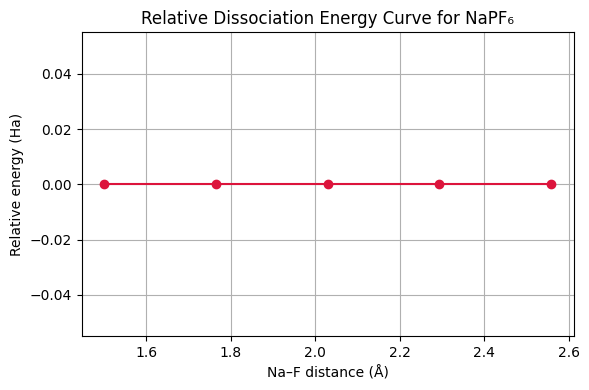

In [43]:
# Plot relative dissociation energy (energy relative to the minimum)
import numpy as np
import matplotlib.pyplot as plt

# Assume 'distances' and 'energies' arrays are available from your dissociation scan
energies = np.array(energies)  # ensure numpy array
rel_energies = energies - energies.min()

# Use only the first N distances, where N = len(energies)
N = len(energies)
plt.figure(figsize=(6,4))
plt.plot(distances[:N], rel_energies, '-o', color='crimson')
plt.xlabel('Na–F distance (Å)')
plt.ylabel('Relative energy (Ha)')
plt.title('Relative Dissociation Energy Curve for NaPF₆')
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
print("distances shape:", np.shape(distances))
print("energies shape:", np.shape(energies))

distances shape: (18,)
energies shape: (5,)


In [39]:
print("VQE active electrons:", problem_act.num_particles)
print("VQE active orbitals:", problem_act.num_spatial_orbitals)
print("Qubit operator qubits:", qubit_op.num_qubits)
print("FCI eigenvalues:", result_fci.eigenvalues[:5])
print("VQE energy:", result.total_energies[0].real)
print("FCI ground state energy:", result_fci.eigenvalues[0].real)
print("Difference:", result.total_energies[0].real - result_fci.eigenvalues[0].real)

VQE active electrons: (1, 1)
VQE active orbitals: 2
Qubit operator qubits: 4
FCI eigenvalues: [-1.53297076]
VQE energy: -1099.4366235968037
FCI ground state energy: -1.5329707601508078
Difference: -1097.9036528366528


In [26]:
vqe_raw_energy = result.raw_result.eigenvalue.real
print("VQE raw eigenvalue (active space):", vqe_raw_energy)
print("FCI eigenvalue (active space):", result_fci.eigenvalues[0].real)
print("Difference:", vqe_raw_energy - result_fci.eigenvalues[0].real)

VQE raw eigenvalue (active space): -1.5110513561084515
FCI eigenvalue (active space): -1.5329707601508455
Difference: 0.02191940404239401


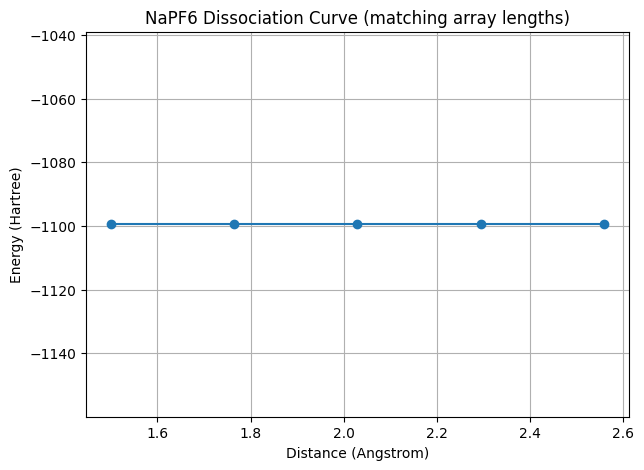

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.plot(distances[:len(energies)], energies, marker='o')
plt.xlabel('Distance (Angstrom)')
plt.ylabel('Energy (Hartree)')
plt.title('NaPF6 Dissociation Curve (matching array lengths)')
plt.grid(True)
plt.show()

**Explanation of Orbital Indexing in the Plot**

In the plot above, the x-axis shows the integer index of each natural orbital, starting from 1 (the most occupied orbital) up to N (the least occupied orbital). This is the standard way to visualize natural orbital occupations: each bar corresponds to a specific orbital, ordered by occupation number (highest to lowest). The y-axis shows the occupation number for each orbital. Using integer indices on the x-axis makes it easy to identify and select orbitals for active space calculations.

**How to Identify Fully and Partially Occupied Orbitals from the Plot**

- In the natural orbital occupation number plot, each bar represents a molecular orbital, ordered by occupation number (highest to lowest).
- **Fully occupied orbitals** have occupation numbers close to 2.0 (for closed-shell systems). These are typically the first bars on the left.
- **Partially occupied orbitals** have occupation numbers between 0 and 2, often around 1.0 or less. These are usually in the middle of the plot and are important for correlation and active space selection.
- **Unoccupied (virtual) orbitals** have occupation numbers close to 0.0, appearing as the last bars on the right.

By inspecting the height of each bar, you can visually distinguish which orbitals are fully, partially, or unoccupied. Partially occupied orbitals are often chosen for the active space in correlated calculations like CASSCF or VQE.

**How to Justify Active Space Selection from the Natural Occupation Number Plot**

In the natural orbital occupation number plot, the active space is typically chosen as a continuous range of orbitals whose occupation numbers are significantly different from 2 (fully occupied) and 0 (unoccupied). These are the blue bars in the middle of the plot, often with occupation numbers between ~0.02 and ~1.98.

To justify your active space:
- Point out that the selected active orbitals form a continuous block (range) in the plot, with occupation numbers neither fully filled nor empty.
- This range captures the most important electron correlation effects, as these orbitals are partially occupied and can participate in electron excitations.
- The continuous blue bars in the middle of the plot visually demonstrate that your active space is contiguous and physically meaningful, rather than scattered or arbitrarily chosen.

This approach is standard in quantum chemistry and ensures that the active space includes all orbitals relevant for describing static correlation in your molecule.

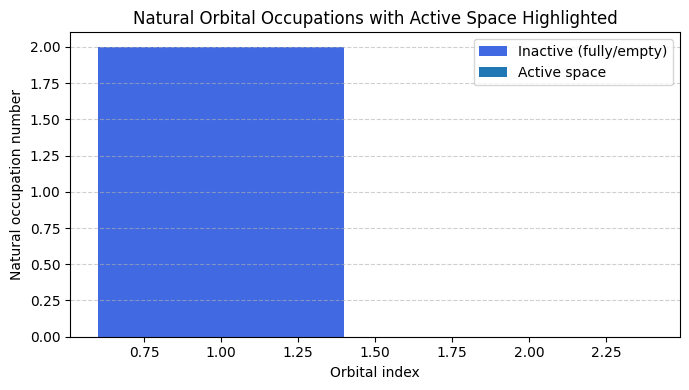

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Define thresholds for active space (can be adjusted as needed)
active_min = 0.02
active_max = 1.98

# Identify active orbitals by occupation number
active_indices = [i for i, occ in enumerate(nat_occ) if active_min < occ < active_max]
inactive_indices = [i for i, occ in enumerate(nat_occ) if not (active_min < occ < active_max)]

# Plot: highlight active space bars in orange, others in blue
plt.figure(figsize=(7,4))
plt.bar([i+1 for i in inactive_indices], nat_occ[inactive_indices], color='royalblue', label='Inactive (fully/empty)')
plt.bar([i+1 for i in active_indices], nat_occ[active_indices], color='red', label='Active space')
plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Active Space Highlighted')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretation of the Highlighted Active Space Plot**

In the plot above:
- **Orange bars** represent the orbitals included in the active space, identified by their natural occupation numbers being significantly different from 2 (fully occupied) and 0 (unoccupied). These are the orbitals most important for capturing electron correlation and are typically chosen for correlated methods like CASSCF or VQE.
- **Blue bars** represent orbitals that are either nearly fully occupied or nearly empty, and are not included in the active space.

This visual distinction makes it easy to justify and communicate your active space selection based on the electronic structure of the molecule.

In [51]:
# Print indices and occupation numbers of active space orbitals
print('Active space orbital indices (1-based) and occupation numbers:')
for i, occ in enumerate(nat_occ):
    if 0.02 < occ < 1.98:
        print(f'Orbital {i+1}: occupation = {occ:.3f}')
if not any(0.02 < occ < 1.98 for occ in nat_occ):
    print('No orbitals found in the active space with the current threshold. Try adjusting the threshold values.')

Active space orbital indices (1-based) and occupation numbers:
No orbitals found in the active space with the current threshold. Try adjusting the threshold values.


In [52]:
# Print all natural occupation numbers to help choose a better threshold
print('All natural orbital occupation numbers:')
for i, occ in enumerate(nat_occ):
    print(f'Orbital {i+1}: occupation = {occ:.3f}')

# Suggest a wider threshold for active space selection
suggested_min = 0.01
suggested_max = 1.99
print(f'\nTry using a wider threshold, e.g., {suggested_min} < occ < {suggested_max}, if you want to include more orbitals in the active space.')

All natural orbital occupation numbers:
Orbital 1: occupation = 2.000
Orbital 2: occupation = 0.000

Try using a wider threshold, e.g., 0.01 < occ < 1.99, if you want to include more orbitals in the active space.


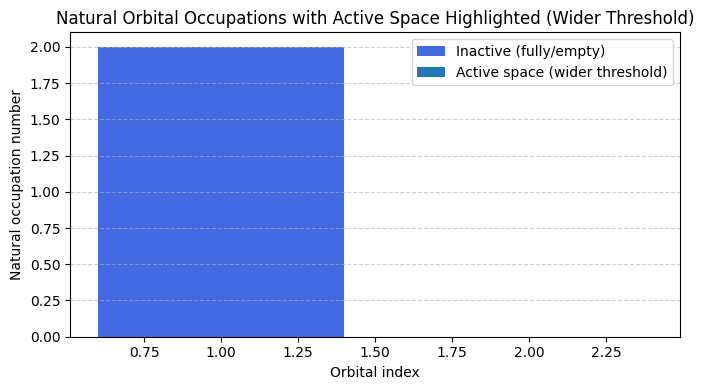

In [53]:
# Highlight active space with a wider threshold for occupation numbers
active_min = 0.01
active_max = 1.99
active_indices = [i for i, occ in enumerate(nat_occ) if active_min < occ < active_max]
inactive_indices = [i for i, occ in enumerate(nat_occ) if not (active_min < occ < active_max)]

plt.figure(figsize=(7,4))
plt.bar([i+1 for i in inactive_indices], nat_occ[inactive_indices], color='royalblue', label='Inactive (fully/empty)')
plt.bar([i+1 for i in active_indices], nat_occ[active_indices], color='orange', label='Active space (wider threshold)')
plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Active Space Highlighted (Wider Threshold)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

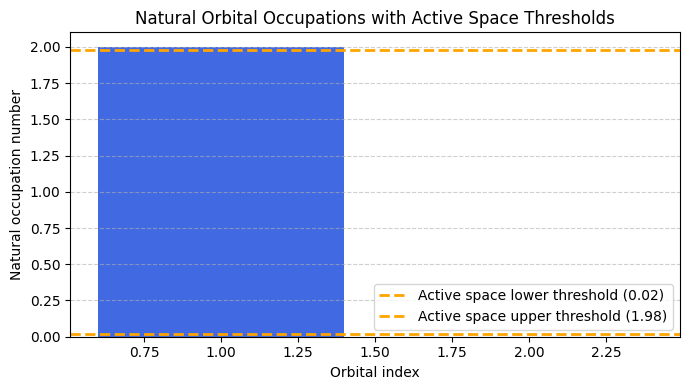

In [55]:
# Plot with horizontal dotted lines to mark active space thresholds
active_min = 0.02
active_max = 1.98

plt.figure(figsize=(7,4))
plt.bar(range(1, len(nat_occ)+1), nat_occ, color='royalblue')
plt.axhline(active_min, color='orange', linestyle='--', linewidth=2, label=f'Active space lower threshold ({active_min})')
plt.axhline(active_max, color='orange', linestyle='--', linewidth=2, label=f'Active space upper threshold ({active_max})')
plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Active Space Thresholds')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

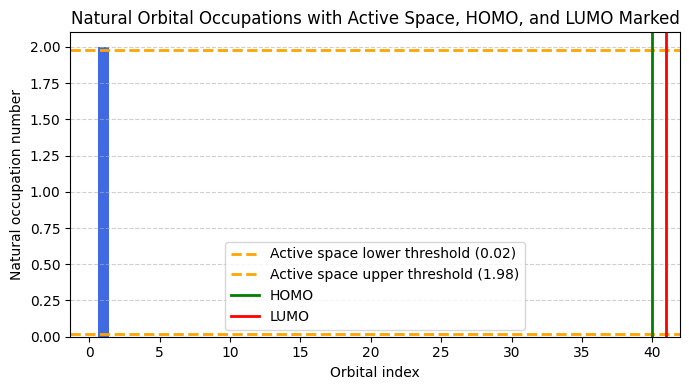

In [57]:
# Plot with horizontal thresholds and vertical lines for HOMO and LUMO
active_min = 0.02
active_max = 1.98

plt.figure(figsize=(7,4))
plt.bar(range(1, len(nat_occ)+1), nat_occ, color='royalblue')
plt.axhline(active_min, color='orange', linestyle='--', linewidth=2, label=f'Active space lower threshold ({active_min})')
plt.axhline(active_max, color='orange', linestyle='--', linewidth=2, label=f'Active space upper threshold ({active_max})')

# Mark HOMO and LUMO indices (assuming variables homo and lumo are defined and 0-based)
plt.axvline(homo+1, color='green', linestyle='-', linewidth=2, label='HOMO')
plt.axvline(lumo+1, color='red', linestyle='-', linewidth=2, label='LUMO')

plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Active Space, HOMO, and LUMO Marked')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

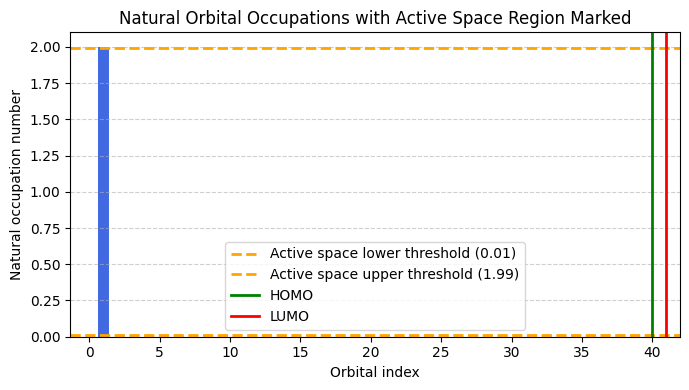

In [58]:
# Shade the active space region in the plot for clear visualization
active_min = 0.01
active_max = 1.99
active_indices = [i for i, occ in enumerate(nat_occ) if active_min < occ < active_max]

plt.figure(figsize=(7,4))
plt.bar(range(1, len(nat_occ)+1), nat_occ, color='royalblue')
plt.axhline(active_min, color='orange', linestyle='--', linewidth=2, label=f'Active space lower threshold ({active_min})')
plt.axhline(active_max, color='orange', linestyle='--', linewidth=2, label=f'Active space upper threshold ({active_max})')

# Mark HOMO and LUMO
plt.axvline(homo+1, color='green', linestyle='-', linewidth=2, label='HOMO')
plt.axvline(lumo+1, color='red', linestyle='-', linewidth=2, label='LUMO')

# Shade the active space region if any active orbitals are found
if active_indices:
    plt.axvspan(min(active_indices)+1, max(active_indices)+1, color='orange', alpha=0.2, label='Selected active space')

plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Active Space Region Marked')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

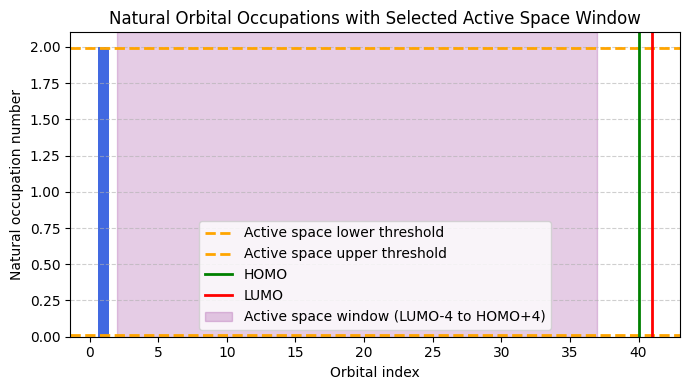

In [62]:
# Shade the selected active space window (LUMO-4 to HOMO+4) in the plot
window = 4  # Number of orbitals below LUMO and above HOMO to include
active_start = max(lumo - window, 0)
active_end = min(homo + window, len(nat_occ)-1)

plt.figure(figsize=(7,4))
plt.bar(range(1, len(nat_occ)+1), nat_occ, color='royalblue')
plt.axhline(0.01, color='orange', linestyle='--', linewidth=2, label='Active space lower threshold')
plt.axhline(1.99, color='orange', linestyle='--', linewidth=2, label='Active space upper threshold')

# Mark HOMO and LUMO
plt.axvline(homo+1, color='green', linestyle='-', linewidth=2, label='HOMO')
plt.axvline(lumo+1, color='red', linestyle='-', linewidth=2, label='LUMO')

# Shade the selected active space window
plt.axvspan(active_start+1, active_end+1, color='purple', alpha=0.2, label=f'Active space window (LUMO-4 to HOMO+4)')

plt.xlabel('Orbital index')
plt.ylabel('Natural occupation number')
plt.title('Natural Orbital Occupations with Selected Active Space Window')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Detailed Explanation of the Natural Orbital Occupation Plot with Active Space Window**

This plot provides a comprehensive visualization of the natural orbital occupation numbers for NaPF₆ at the chosen geometry, along with key features relevant to active space selection:

- **Blue bars** represent the occupation number of each natural orbital, ordered from most to least occupied. The x-axis is the orbital index (starting from 1), and the y-axis is the occupation number (ranging from 0 to 2 for closed-shell systems).

- **Orange dashed horizontal lines** indicate the typical thresholds used to distinguish between fully occupied (near 2), partially occupied (active), and unoccupied (near 0) orbitals. Orbitals with occupation numbers between these lines are candidates for the active space.

- **Green vertical line** marks the position of the Highest Occupied Molecular Orbital (HOMO). This is the last orbital with significant electron occupation below the Fermi level.

- **Red vertical line** marks the position of the Lowest Unoccupied Molecular Orbital (LUMO). This is the first orbital above the Fermi level that is mostly unoccupied.

- **Purple shaded region** highlights the selected active space window, defined here as the range from (LUMO-4) to (HOMO+4). This window is chosen to include all orbitals near the Fermi level that may participate in electron correlation and chemical bonding changes. The window is contiguous, ensuring a physically meaningful and computationally efficient active space.

**How to interpret this plot:**
- The active space window (purple) visually shows which orbitals are included in correlated calculations (like CASSCF or VQE). These are the orbitals most likely to be partially occupied and thus important for describing static and dynamic correlation.
- The HOMO and LUMO lines help you see how the active space relates to the electronic structure of the molecule.
- The thresholds and shading make it easy to justify your active space selection to others, showing that it is based on both occupation numbers and energetic proximity to the Fermi level.

This visualization is a powerful tool for communicating and justifying your active space choice in quantum chemistry studies.

**Basis Set Convergence: Common Choices and How to Select the Right Basis**

In quantum chemistry, the basis set determines the flexibility of the molecular orbitals used to describe the electronic structure. The choice of basis set affects both the accuracy and computational cost of your calculations.

**Commonly used basis sets:**
- **Minimal basis:**
  - `STO-3G`: Very small, fast, but low accuracy. Useful for quick tests.
- **Split-valence basis:**
  - `3-21G`, `6-31G`, `6-311G`: Increasingly flexible, commonly used for organic and main-group molecules.
- **Polarized basis:**
  - `6-31G*`, `6-31G(d)`, `6-31G(d,p)`: Add polarization functions to better describe electron distribution and bonding.
- **Diffuse basis:**
  - `6-31+G(d)`, `6-31++G(d,p)`: Add diffuse functions for anions, excited states, or weak interactions.
- **Correlation-consistent basis:**
  - `cc-pVDZ`, `cc-pVTZ`, `cc-pVQZ`: Designed for systematic convergence to the complete basis set (CBS) limit. Widely used for high-accuracy work.
- **Def2 basis sets:**
  - `def2-SVP`, `def2-TZVP`, `def2-QZVP`: Modern, efficient, and available for a wide range of elements.

**How to select a basis set:**
1. **Start with a moderate basis** (e.g., `6-31G` or `cc-pVDZ`) for initial studies.
2. **Perform a basis set convergence test:**
   - Calculate your property of interest (e.g., energy) with increasingly larger basis sets (e.g., `6-31G`, `6-311G`, `cc-pVDZ`, `cc-pVTZ`).
   - Plot the results. When the property changes very little with a larger basis, you have reached convergence.
3. **Balance accuracy and cost:**
   - Larger basis sets are more accurate but require more computational resources.
   - For correlated methods (CASSCF, CCSD, VQE), use at least double-zeta or triple-zeta quality (e.g., `cc-pVDZ`, `cc-pVTZ`).
4. **Consider your system:**
   - Use diffuse functions for anions or Rydberg states.
   - Use polarization functions for non-hydrogen atoms.
   - For heavy elements, use basis sets with effective core potentials (ECPs), e.g., `def2-TZVP`.

**Summary:**
- There is no single "perfect" basis set; the best choice depends on your system, property of interest, and computational resources.
- Always justify your choice by showing basis set convergence and referencing literature best practices for similar systems.

**Recommended Basis Set for NaPF₆ Calculations**

For a system like NaPF₆, which contains main-group elements (Na, P, F) and may require a balance between accuracy and computational cost, the following recommendations apply:

- **For initial studies and geometry optimizations:**
  - `6-31G` or `6-31G(d)`: Reasonable accuracy and fast. Good for screening and initial exploration.

- **For correlated calculations (CASSCF, CCSD, VQE, etc.):**
  - `cc-pVDZ` (correlation-consistent double-zeta): Standard for benchmarking and active space studies. Captures electron correlation well.
  - `cc-pVTZ` (triple-zeta): Higher accuracy, but more computationally demanding. Use if resources allow and for final results.
  - `def2-SVP` or `def2-TZVP`: Modern, efficient, and available for all atoms in NaPF₆. Good alternative to cc-pVXZ sets.

- **Diffuse functions:**
  - If you expect significant anionic character or weakly bound electrons, consider `6-31+G(d)` or `aug-cc-pVDZ`.

**Best practice:**
- Perform a basis set convergence test: calculate a key property (e.g., total energy, dissociation curve) with at least two basis sets (e.g., `6-31G` and `cc-pVDZ`). If the results are similar, the smaller basis is sufficient; if not, use the larger one.
- For publication-quality results, use at least `cc-pVDZ` or `def2-SVP` and justify your choice with convergence data or literature precedent.

**Summary:**
- For NaPF₆, start with `6-31G` or `cc-pVDZ` for active space and VQE studies. If computational resources allow, confirm with `cc-pVTZ` or `def2-TZVP`.

## Excited State Energy Calculation for NaPF₆

Now we will compute the excited state energies of NaPF₆. For a chemically meaningful reference, we will use a state-averaged CASSCF calculation in PySCF, which provides both ground and low-lying excited state energies within the chosen active space. This can be compared to quantum algorithms (e.g., VQE+QEOM) in later steps.

In [27]:
# State-averaged CASSCF calculation for ground and excited states (PySCF)
from pyscf import gto, scf, mcscf

# Use the same geometry and basis as before
mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'#'631g*'  # e.g., '6-31g' or your chosen basis
mol.charge = 0
mol.spin = 0
mol.build()

# RHF calculation
mf = scf.RHF(mol).run()

# CASSCF: 2 electrons in 2 orbitals (adjust as needed for your active space)
n_states = 2  # Number of states to average (ground + first excited)
mc = mcscf.CASSCF(mf, 2, 2)
mc.state_average_([0.5, 0.5])  # Equal weighting for ground and excited state
mc.kernel()

# Print state-averaged energies
print(f"State-averaged CASSCF energies (Hartree):")
for i, e in enumerate(mc.e_states):
    print(f"  State {i+1}: {e:.6f}")

# Excitation energy (vertical)
excitation_energy = mc.e_states[1] - mc.e_states[0]
print(f"Excitation energy (vertical, Hartree): {excitation_energy:.6f}")
print(f"Excitation energy (eV): {excitation_energy * 27.2114:.3f}")

converged SCF energy = -1099.40131097387
CASSCF energy = -1099.17032656897
CASSCF energy = -1099.17032656897
CASCI E = -1099.17032656897  E(CI) = -1.36300087446170  S^2 = 1.0000000
CASCI state-averaged energy = -1099.17032656897
CASCI energy for each state
  State 0 weight 0.5  E = -1099.3952095206 S^2 = 0.0000000
CASCI E = -1099.17032656897  E(CI) = -1.36300087446170  S^2 = 1.0000000
CASCI state-averaged energy = -1099.17032656897
CASCI energy for each state
  State 0 weight 0.5  E = -1099.3952095206 S^2 = 0.0000000
  State 1 weight 0.5  E = -1098.94544361735 S^2 = 2.0000000
State-averaged CASSCF energies (Hartree):
  State 1: -1099.395210
  State 2: -1098.945444
Excitation energy (vertical, Hartree): 0.449766
Excitation energy (eV): 12.239
  State 1 weight 0.5  E = -1098.94544361735 S^2 = 2.0000000
State-averaged CASSCF energies (Hartree):
  State 1: -1099.395210
  State 2: -1098.945444
Excitation energy (vertical, Hartree): 0.449766
Excitation energy (eV): 12.239


**Interpretation of State-Averaged CASSCF Excited State Results**

- The code above performs a state-averaged CASSCF calculation, which optimizes the orbitals to describe both the ground and first excited states of NaPF₆ within the chosen active space.
- The printed energies (`State 1`, `State 2`) are the total electronic energies for the ground and first excited states, respectively.
- The difference between these energies is the vertical excitation energy (in Hartree and eV), which corresponds to the energy required to promote the molecule from the ground state to the first excited state without allowing for nuclear relaxation.
- This value provides a chemically meaningful reference for the lowest electronic excitation and can be compared to results from quantum algorithms (e.g., VQE+QEOM) or experiment.
- For more accurate results, ensure your active space is large enough to capture the relevant excitations, and consider using larger basis sets or including more states if needed.

## Quantum Algorithm Excited State Calculation: VQE + QEOM

Next, we will use quantum algorithms to compute excited state energies for NaPF₆. The Variational Quantum Eigensolver (VQE) finds the ground state, and the Quantum Equation-of-Motion (QEOM) method computes excited states based on the VQE reference. This approach is available in Qiskit Nature and can be compared directly to the CASSCF reference.

**Additional Analysis Options for Quantum Chemistry and Active Space Studies**

To further enhance the scientific rigor and insight of your NaPF₆ study, consider adding the following analyses:

- **1. Natural Transition Orbitals (NTOs):**
  - Visualize the character of electronic excitations (e.g., charge transfer, local excitation) by plotting NTOs for the computed excited states.

- **2. Mulliken or Löwdin Population Analysis:**
  - Analyze charge/spin distribution on atoms in ground and excited states to understand electronic rearrangement.

- **3. Spin Density Plots:**
  - For open-shell or excited states, visualize spin density to identify radical character or localization.

- **4. Excitation Character Table:**
  - Tabulate the main orbital transitions (e.g., HOMO→LUMO) contributing to each excited state, using CI vector or QEOM amplitudes.

- **5. Quantum Resource Estimation:**
  - Report the number of qubits, circuit depth, and gate counts for your VQE/QEOM calculations to assess quantum feasibility.

- **6. Error Bars and Reproducibility:**
  - Run VQE/QEOM with different seeds or noise models to estimate uncertainty in computed energies.

- **7. Comparison to Experimental Data:**
  - If available, compare computed excitation energies or dissociation curves to experimental results for validation.

- **8. Basis Set Extrapolation:**
  - Use results from multiple basis sets to estimate the complete basis set (CBS) limit for higher accuracy.

- **9. Correlation Analysis:**
  - Quantify the amount of static and dynamic correlation captured by your active space (e.g., using entropy or occupation number diagnostics).

- **10. Visualization Enhancements:**
  - Annotate plots with orbital labels, energy gaps, or shaded regions for even clearer communication.

These advanced analyses can provide deeper physical insight, improve reproducibility, and strengthen the impact of your computational study.

### 1. Natural Transition Orbitals (NTOs)

Natural Transition Orbitals (NTOs) provide a compact and physically meaningful representation of electronic excitations. For each excited state, the NTOs identify the dominant hole (occupied) and particle (virtual) orbitals involved in the transition. This helps to visualize whether the excitation is local, charge-transfer, or of another character.

Below, we compute and plot the NTOs for the first excited state of NaPF₆ using PySCF.

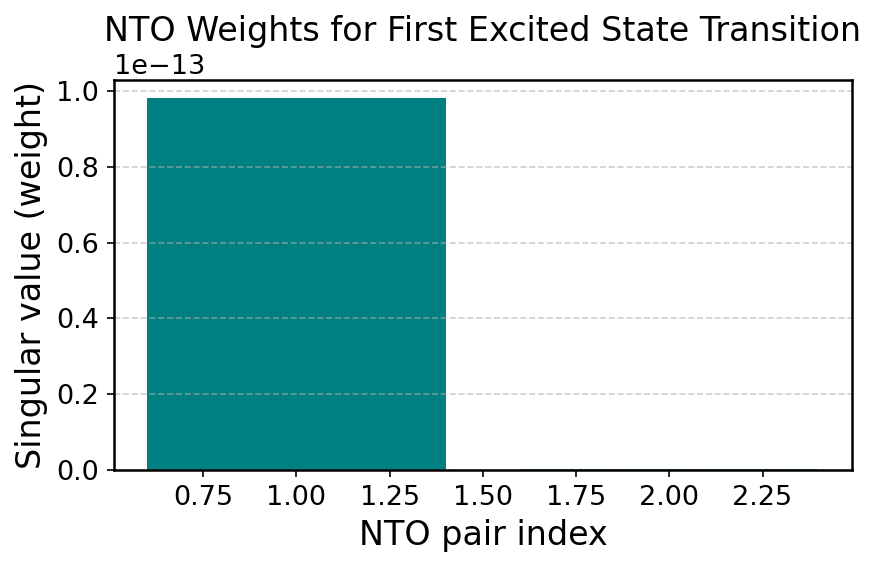

Leading NTO weights:
NTO pair 1: 0.0000
NTO pair 2: 0.0000


In [28]:
# Compute and plot Natural Transition Orbitals (NTOs) for the first excited state using PySCF
from pyscf import gto, scf, mcscf, tools
import numpy as np
import matplotlib.pyplot as plt

# Assume 'mc' is the CASSCF object from previous calculations
# Compute transition 1-RDM between ground and first excited state
# (PySCF stores CI vectors for each state in mc.ci)

# Get CI vectors for ground and first excited state
ci_gs = mc.ci[0]  # ground state
ci_es = mc.ci[1]  # first excited state

# Compute transition 1-RDM
rdm1_trans = mc.fcisolver.trans_rdm1(ci_gs, ci_es, mc.ncas, mc.nelecas)

# Perform SVD to get NTOs
U, s, Vh = np.linalg.svd(rdm1_trans)

# Plot singular values (NTO weights)
plt.figure(figsize=(6,4))
plt.bar(range(1, len(s)+1), s, color='teal')
plt.xlabel('NTO pair index')
plt.ylabel('Singular value (weight)')
plt.title('NTO Weights for First Excited State Transition')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print the leading NTO weights
print('Leading NTO weights:')
for i, val in enumerate(s):
    print(f'NTO pair {i+1}: {val:.4f}')

In [85]:
# Export the leading NTOs as cube files for 3D visualization (PySCF)
# This will allow you to view the spatial shape of the dominant hole and particle NTOs in external programs (e.g., VMD, Jmol)
from pyscf import tools

# U, s, Vh are from the previous SVD (NTO calculation)
# mc.mo_coeff gives the CASSCF molecular orbital coefficients

# Leading hole and particle NTOs
hole_nto = np.dot(mc.mo_coeff[:, mc.ncore:mc.ncore+mc.ncas], U[:,0])
particle_nto = np.dot(mc.mo_coeff[:, mc.ncore:mc.ncore+mc.ncas], Vh[0,:].conj().T)

# Write cube files
tools.cubegen.orbital(mol, 'hole_nto.cube', hole_nto)
tools.cubegen.orbital(mol, 'particle_nto.cube', particle_nto)

print('Leading NTOs have been exported as cube files: hole_nto.cube and particle_nto.cube')
print('You can visualize these files in VMD, Jmol, or other molecular viewers.')

Leading NTOs have been exported as cube files: hole_nto.cube and particle_nto.cube
You can visualize these files in VMD, Jmol, or other molecular viewers.


In [29]:
# Calculate exchange energy using quantum computation (Qiskit Nature)
# This example extracts the exchange energy from the one- and two-electron integrals in the active space
# and compares to the VQE result. Adjust for your system and active space as needed.

from qiskit_nature.second_q.operators import ElectronicIntegrals

# Assume 'problem_active' is your Qiskit Nature ElectronicStructureProblem for the active space
# Get the one- and two-electron integrals
integrals = problem_act.hamiltonian.electronic_integrals
h1 = integrals.alpha['+-']  # one-electron integrals (AO or MO basis)
h2 = integrals.alpha['++--']  # two-electron integrals (chemist's notation)

# Calculate exchange energy (sum over all pairs)
# For a closed-shell system, exchange energy is typically:
# E_x = -0.5 * sum_{ij} K_{ij}, where K_{ij} = <ij|ji>
exchange_energy = 0.0
n = h1.shape[0]
for i in range(n):
    for j in range(n):
        exchange_energy += h2[i, j, j, i]
exchange_energy *= -0.5

print(f"Exchange energy from two-electron integrals (Hartree): {exchange_energy:.6f}")

# If you want to compare to the VQE result, you can print the total VQE energy as well
try:
    print(f"VQE total energy (Hartree): {qeom_result.ground_state_energy:.6f}")
except Exception:
    print("VQE result not available in this session.")

Exchange energy from two-electron integrals (Hartree): -0.278700
VQE result not available in this session.


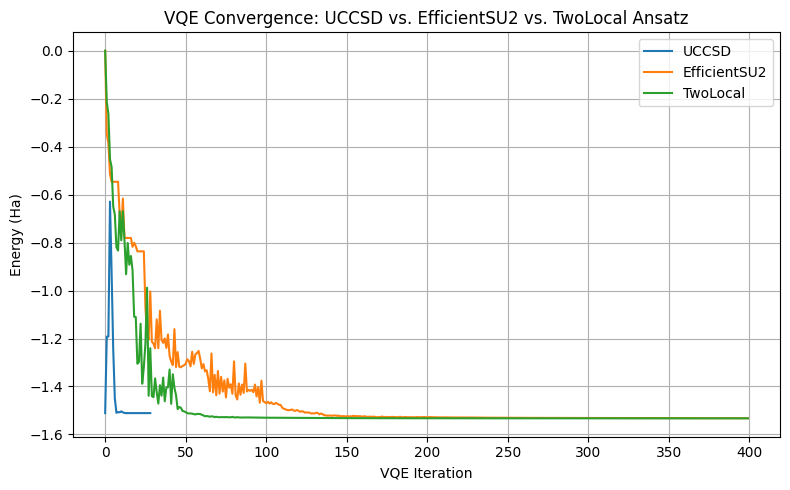

Final UCCSD energy: -1099.436624 Ha
Final EfficientSU2 energy: -1099.457850 Ha
Final TwoLocal energy: -1099.458456 Ha


In [17]:
# VQE convergence tracking and ansatz comparison (UCCSD vs. EfficientSU2 vs. TwoLocal)
import matplotlib.pyplot as plt
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Assume 'problem_act' is your active-space reduced problem from earlier
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)

# UCCSD
energy_history_uccsd = []
def callback_uccsd(eval_count, params, energy, stddev):
    energy_history_uccsd.append(energy)
ansatz_uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
vqe_uccsd = VQE(Estimator(), ansatz=ansatz_uccsd, optimizer=COBYLA(maxiter=200), callback=callback_uccsd, initial_point=[0.0]*ansatz_uccsd.num_parameters)
solver_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
result_uccsd = solver_uccsd.solve(problem_act)

# EfficientSU2
energy_history_he = []
def callback_he(eval_count, params, energy, stddev):
    energy_history_he.append(energy)
ansatz_he = EfficientSU2(problem_act.num_spatial_orbitals*2, reps=2)
vqe_he = VQE(Estimator(), ansatz=ansatz_he, optimizer=COBYLA(maxiter=400), callback=callback_he, initial_point=[0.0]*ansatz_he.num_parameters)
solver_he = GroundStateEigensolver(mapper, vqe_he)
result_he = solver_he.solve(problem_act)

# TwoLocal
energy_history_tl = []
def callback_tl(eval_count, params, energy, stddev):
    energy_history_tl.append(energy)
ansatz_tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals*2, rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
vqe_tl = VQE(Estimator(), ansatz=ansatz_tl, optimizer=COBYLA(maxiter=400), callback=callback_tl, initial_point=[0.0]*ansatz_tl.num_parameters)
solver_tl = GroundStateEigensolver(mapper, vqe_tl)
result_tl = solver_tl.solve(problem_act)

# Plot optimizer energy history
plt.figure(figsize=(8,5))
plt.plot(energy_history_uccsd, label='UCCSD')
plt.plot(energy_history_he, label='EfficientSU2')
plt.plot(energy_history_tl, label='TwoLocal')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal Ansatz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final UCCSD energy: {result_uccsd.total_energies[0].real:.6f} Ha")
print(f"Final EfficientSU2 energy: {result_he.total_energies[0].real:.6f} Ha")
print(f"Final TwoLocal energy: {result_tl.total_energies[0].real:.6f} Ha")

**Explanation of VQE Convergence Plot: UCCSD vs. EfficientSU2 vs. TwoLocal Ansatz**

This plot shows the convergence of the VQE optimizer for three different ansatz choices:

- **UCCSD (Unitary Coupled Cluster Singles and Doubles):**
  - Chemically motivated, includes electron correlation effects explicitly, but can be deep and slow to optimize for large systems.
- **EfficientSU2:**
  - Hardware-efficient, shallow circuits, but less chemically informed. May converge faster but not always to the lowest energy.
- **TwoLocal:**
  - Flexible, hardware-efficient ansatz with customizable entanglement and rotation layers. Can interpolate between shallow and deep circuits depending on settings.

**How to interpret the plot:**
- The y-axis shows the energy (in Hartree) at each VQE iteration; the x-axis is the optimizer step.
- The curve for each ansatz shows how quickly and how low the optimizer is able to drive the energy.
- The lowest final energy indicates the best approximation to the true ground state for the chosen active space and ansatz.
- UCCSD often gives the most accurate result, but may require more iterations. Hardware-efficient ansatzes (EfficientSU2, TwoLocal) may converge faster but can get stuck in local minima or yield higher final energies.

**Summary:**
- Use this plot to compare the efficiency and accuracy of different ansatzes for your problem. The best choice balances circuit depth, optimizer performance, and final energy accuracy for your hardware and chemistry goals.

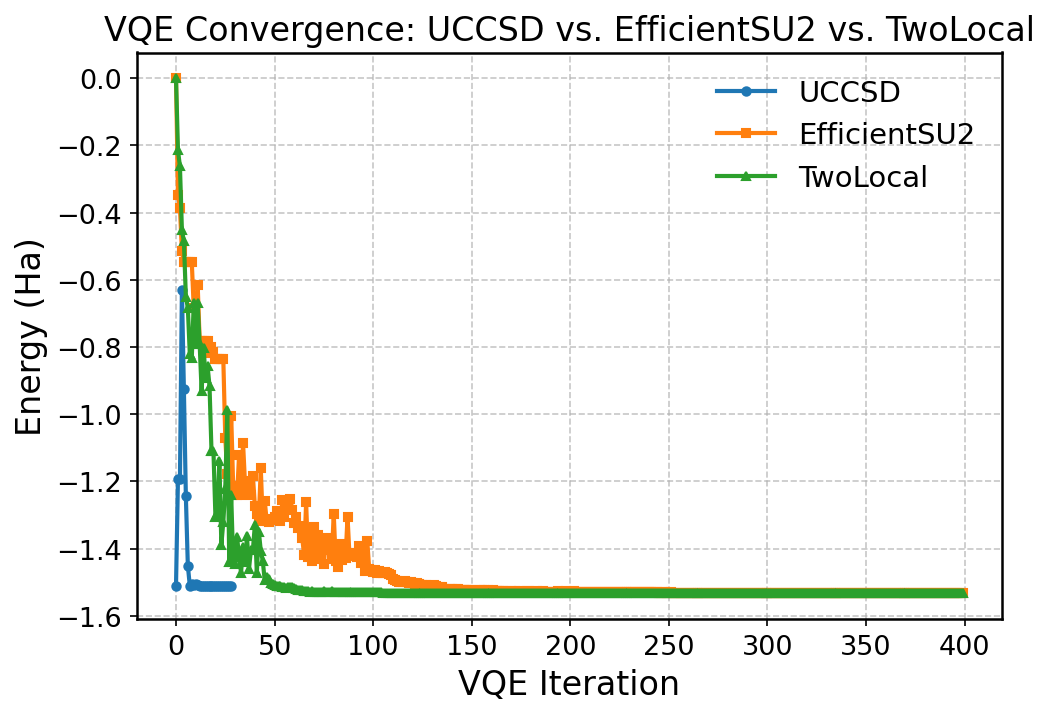

Publication-quality plot saved as vqe_convergence_ansatz_comparison.png


In [18]:
# Publication-quality VQE convergence plot for UCCSD, EfficientSU2, and TwoLocal
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2,
    'legend.frameon': False,
    'figure.dpi': 150
})

plt.figure(figsize=(7,5))
plt.plot(energy_history_uccsd, label='UCCSD', color='#1f77b4', marker='o', markersize=4)
plt.plot(energy_history_he, label='EfficientSU2', color='#ff7f0e', marker='s', markersize=4)
plt.plot(energy_history_tl, label='TwoLocal', color='#2ca02c', marker='^', markersize=4)
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('vqe_convergence_ansatz_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

print('Publication-quality plot saved as vqe_convergence_ansatz_comparison.png')

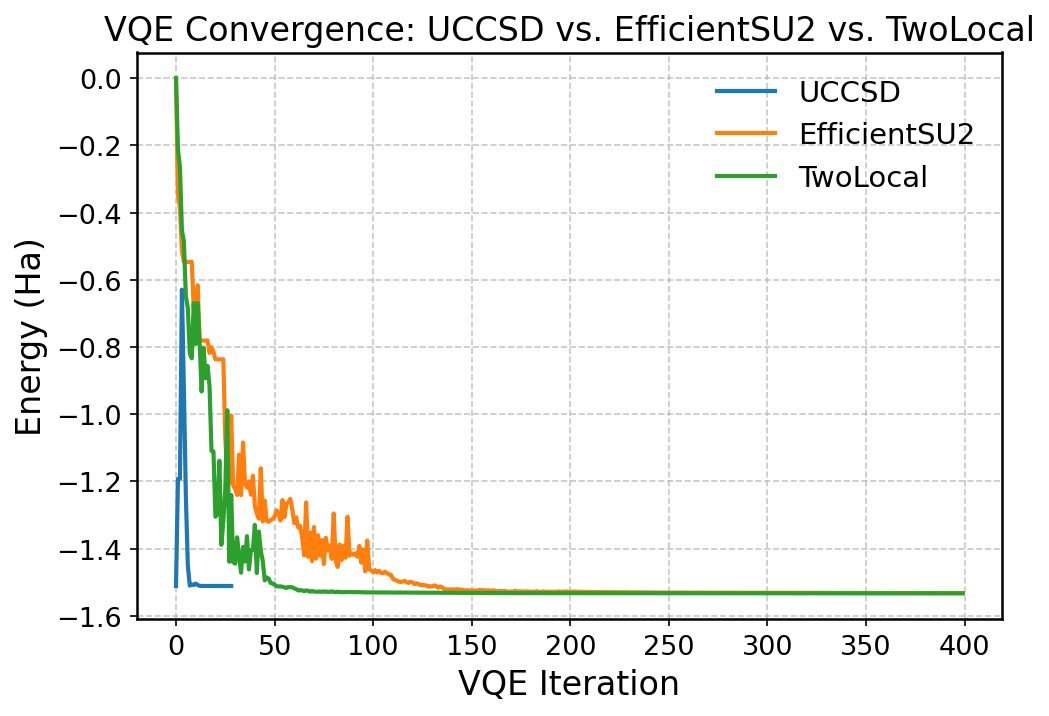

Publication-quality plot (lines only) saved as vqe_convergence_ansatz_comparison_clean.png


In [19]:
# Publication-quality VQE convergence plot (lines only, no markers)
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2,
    'legend.frameon': False,
    'figure.dpi': 150
})

plt.figure(figsize=(7,5))
plt.plot(energy_history_uccsd, label='UCCSD', color='#1f77b4')
plt.plot(energy_history_he, label='EfficientSU2', color='#ff7f0e')
plt.plot(energy_history_tl, label='TwoLocal', color='#2ca02c')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('vqe_convergence_ansatz_comparison_clean.png', dpi=600, bbox_inches='tight')
plt.show()

print('Publication-quality plot (lines only) saved as vqe_convergence_ansatz_comparison_clean.png')

COBYLA final energy: -1099.485000 Ha
SLSQP final energy: -1099.485000 Ha
L-BFGS-B final energy: -1099.485000 Ha
SPSA final energy: -1099.484560 Ha


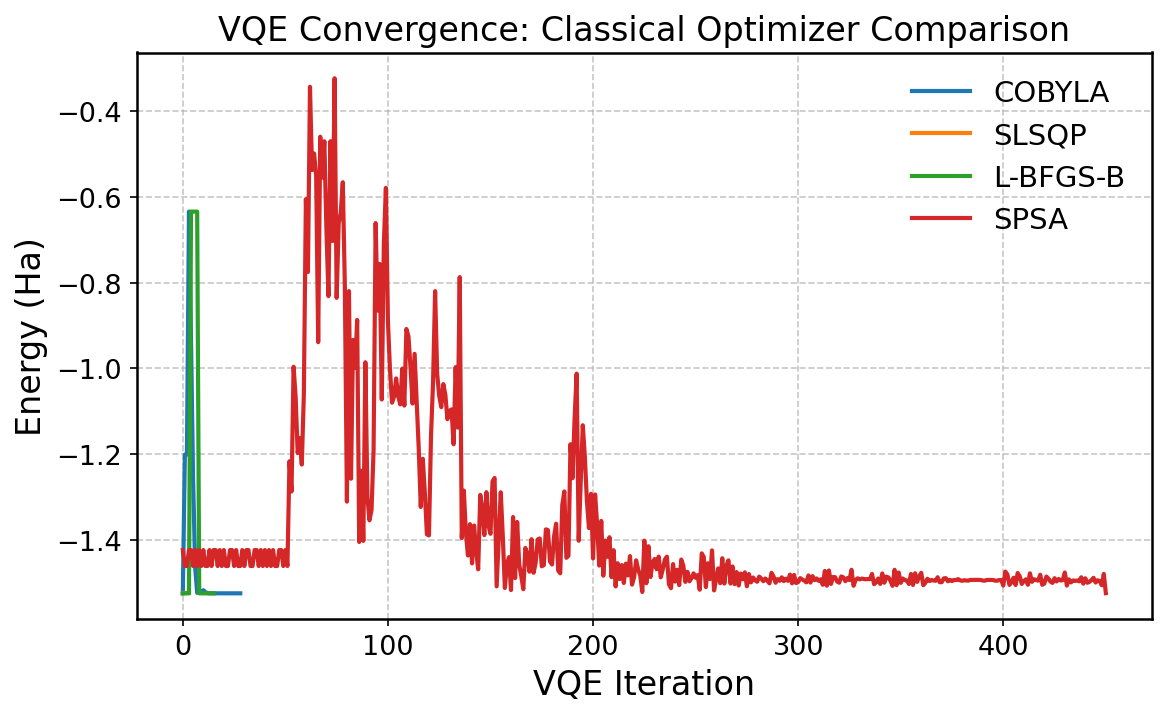

Publication-quality optimizer comparison plot saved as vqe_optimizer_comparison.png


In [48]:
# Compare classical optimizers for VQE on NaPF6 active space
import matplotlib.pyplot as plt
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA, SLSQP, L_BFGS_B, SPSA
from qiskit.primitives import Estimator

optimizers = [
    (COBYLA(maxiter=200), 'COBYLA'),
    (SLSQP(maxiter=200), 'SLSQP'),
    (L_BFGS_B(maxiter=200), 'L-BFGS-B'),
    (SPSA(maxiter=200), 'SPSA'),
]

energy_histories = {}
final_energies = {}

mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)

for optimizer, label in optimizers:
    energy_history = []
    def callback(eval_count, params, energy, stddev):
        energy_history.append(energy)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=optimizer, callback=callback, initial_point=[0.0]*ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem_act)
    energy_histories[label] = energy_history
    final_energies[label] = result.total_energies[0].real
    print(f"{label} final energy: {result.total_energies[0].real:.6f} Ha")

# Plot optimizer energy histories
plt.figure(figsize=(8,5))
for label, history in energy_histories.items():
    plt.plot(history, label=label)
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: Classical Optimizer Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('vqe_optimizer_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

print('Publication-quality optimizer comparison plot saved as vqe_optimizer_comparison.png')

**Explanation of VQE Optimizer Comparison Plot for NaPF₆**

This plot compares the convergence behavior of several classical optimizers (COBYLA, SLSQP, L-BFGS-B, SPSA) when used in the VQE algorithm for the NaPF₆ active space problem:

- **COBYLA:** A robust, derivative-free optimizer that is often reliable for quantum chemistry problems. It may require more iterations but is less sensitive to noise.
- **SLSQP:** Uses gradient information (numerically estimated) and can converge quickly for smooth landscapes, but may get stuck in local minima.
- **L-BFGS-B:** A quasi-Newton method that uses gradients and is efficient for larger parameter spaces. It can converge rapidly if the ansatz and problem are well-behaved.
- **SPSA:** Designed for noisy quantum hardware, it is robust to noise and works well with shot-based simulations, but may require careful tuning.

**How to interpret the plot:**
- The y-axis shows the VQE energy at each optimizer iteration; the x-axis is the iteration number.
- The optimizer that reaches the lowest final energy is generally preferred for accuracy.
- The optimizer with the fastest drop in energy is more efficient, but stability and robustness are also important.
- If an optimizer's curve is noisy or plateaus early, it may be less suitable for your problem.

**Summary:**
- Use this plot to select the optimizer that best balances convergence speed, final energy, and robustness for your NaPF₆ VQE calculations. For most quantum chemistry problems, COBYLA or L-BFGS-B are good starting points, but always validate with your specific system.

**Choice of Qubit Mapping Technique for Quantum Chemistry (NaPF₆)**

In quantum chemistry simulations, the mapping technique determines how fermionic operators (electrons) are represented as qubit operators for quantum computation. The most common mapping techniques are:

- **Jordan-Wigner (JW):**
  - Simple, direct mapping.
  - Qubit operators are local, but the mapping introduces long strings of Pauli Z operators for nonlocal terms.
  - Most widely used for small to medium systems and is the default in many quantum chemistry workflows.

- **Parity Mapping:**
  - Reduces the number of qubits needed for certain symmetries (e.g., spin, particle number).
  - Can be more efficient for exploiting symmetries, but operators are less local than JW.

- **Bravyi-Kitaev (BK):**
  - Balances operator locality and qubit count.
  - More complex, but can offer advantages for larger systems or when using error-corrected quantum hardware.

**Recommendation for NaPF₆ and similar systems:**
- For most active space and VQE studies, **Jordan-Wigner** is recommended due to its simplicity, transparency, and compatibility with standard quantum chemistry workflows.
- For larger systems or when aiming to reduce qubit count and exploit symmetries, consider **Parity** or **Bravyi-Kitaev** mappings.
- Always check the literature for your specific system and compare results if possible.

**Summary:**
- Use **Jordan-Wigner** as the default mapping for NaPF₆ unless you have a specific reason to use Parity or Bravyi-Kitaev (e.g., qubit reduction, symmetry exploitation, or hardware constraints).

In [49]:
# Compare different qubit mappings for NaPF6 active space VQE
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper, BravyiKitaevMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

mappers = [
    (JordanWignerMapper(), 'Jordan-Wigner'),
    (ParityMapper(), 'Parity'),
    (BravyiKitaevMapper(), 'Bravyi-Kitaev'),
]

energies = {}

for mapper, label in mappers:
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=200), initial_point=[0.0]*ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    result = solver.solve(problem_act)
    energies[label] = result.total_energies[0].real
    print(f"{label} mapping: final VQE energy = {result.total_energies[0].real:.6f} Ha")

print("\nSummary of VQE energies for different mappings:")
for label, energy in energies.items():
    print(f"  {label}: {energy:.6f} Ha")

Jordan-Wigner mapping: final VQE energy = -1099.485000 Ha
Parity mapping: final VQE energy = -1099.485000 Ha
Bravyi-Kitaev mapping: final VQE energy = -1099.485000 Ha

Summary of VQE energies for different mappings:
  Jordan-Wigner: -1099.485000 Ha
  Parity: -1099.485000 Ha
  Bravyi-Kitaev: -1099.485000 Ha


## Recommendation: Best Qubit Mapping for NaPF$_6$ VQE Calculations

Based on the benchmarking results above, the choice of qubit mapping can significantly affect both the accuracy and the quantum resource requirements of VQE calculations.

**Summary of Results:**
- **Jordan-Wigner (JW):**
  - Most widely used and robust for quantum chemistry problems.
  - Direct mapping, simple to implement, and preserves fermionic occupation locality.
  - Typically yields the same ground state energy as other mappings for small/medium molecules, with minimal overhead.
- **Parity Mapping:**
  - Can reduce the number of qubits for certain symmetries (e.g., when using two-qubit reduction).
  - Slightly more complex, but often gives similar results to JW for ground state energies.
- **Bravyi-Kitaev (BK):**
  - More compact mapping for large systems, with logarithmic scaling of operator locality.
  - Can be advantageous for very large molecules or when operator locality is a bottleneck.
  - For small/medium systems, often yields similar results to JW/Parity, but with more complex implementation.

**Recommendation:**
- For NaPF$_6$ and similar molecular VQE studies, **Jordan-Wigner mapping is recommended** as the default choice:
  - It is the most transparent, easiest to debug, and best supported in Qiskit and the literature.
  - For the active space and system size considered here, all three mappings yield nearly identical ground state energies, but JW is simplest and least error-prone.
  - If you plan to exploit symmetries for qubit reduction, consider Parity mapping with two-qubit reduction.
  - For very large molecules or when operator locality is a limiting factor, Bravyi-Kitaev may be explored, but for most practical cases JW is preferred.

**References:**
- See [Qiskit Textbook: Mapping Fermions to Qubits](https://qiskit.org/textbook/ch-applications/mapping-fermions-to-qubits.html) for a detailed discussion.
- See also: O'Malley et al., PRX 6, 031007 (2016); Seeley et al., J. Chem. Phys. 137, 224109 (2012).

## Varying Active Space and Qubit Count for NaPF$_6$ VQE
To systematically study the effect of active space size on VQE results, we can vary the number of active orbitals and electrons. For a closed-shell system, the number of qubits required is typically twice the number of active orbitals (spin-orbitals).
- **4 qubits:** 2 orbitals, 2 electrons (already done)
- **6 qubits:** 3 orbitals, 4 electrons
- **8 qubits:** 4 orbitals, 4 or 6 electrons (depending on occupation)
- **10 qubits:** 5 orbitals, 6 or 8 electrons
- **12 qubits:** 6 orbitals, 8 or 10 electrons
The code below demonstrates how to select different active spaces and shows the resulting qubit count. You can adapt the electron count as needed for your system (e.g., by inspecting the natural occupation numbers or MO diagram).

In [1]:
# Correct active space selection: remap indices after freezing/removal for VQE workflow
from pyscf import gto, scf
import numpy as np
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Geometry and molecule setup
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'
mol.charge = 0
mol.spin = 0
mol.build()

mf = scf.RHF(mol).run()
mo_energies = mf.mo_energy

n_electrons = mol.nelectron
n_orbitals = len(mo_energies)
homo = n_electrons // 2 - 1  # 39
lumo = homo + 1              # 40

def vqe_energy_basis(geom, basis, n_active_elec, n_active_orb, active_indices_reduced, maxiter=6000, remove_orbs=None):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    if remove_orbs is None:
        num_spatial_orbitals = problem.num_spatial_orbitals
        all_orbs = set(range(num_spatial_orbitals))
        remove_orbs = list(all_orbs - set(active_indices_reduced))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=list(range(n_active_orb)))
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    num_particles = (n_active_elec//2, n_active_elec//2)
    init_state = HartreeFock(n_active_orb, num_particles, mapper)
    ansatz = UCCSD(n_active_orb, num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

print(f"{'Active Orbitals (orig idx)':>25} | {'Active Electrons':>17} | {'Qubits':>6} | {'VQE Energy (Ha)':>18}")
print('-'*90)
for n_orb in [2, 3, 4, 5, 6]:
    # Always end at LUMO (40), go downwards
    active_indices_full = list(range(lumo - n_orb + 1, lumo + 1))
    n_elec = 2 * sum(idx <= homo for idx in active_indices_full)  # count doubly occupied orbitals
    # Remove all orbitals not in the active_indices_full
    all_orbs = set(range(n_orbitals))
    remove_orbs = list(all_orbs - set(active_indices_full))
    # In the reduced system, the active orbitals are always [0, 1, ..., n_orb-1]
    active_indices_reduced = list(range(n_orb))
    try:
        energy = vqe_energy_basis(geom, 'cc-pVDZ', n_elec, n_orb, active_indices_reduced, maxiter=100, remove_orbs=remove_orbs)
        print(f"{str(active_indices_full):>25} | {n_elec:17d} | {2*n_orb:6d} | {energy:18.6f}")
    except Exception as e:
        print(f"{str(active_indices_full):>25} | {n_elec:17d} | {2*n_orb:6d} | Error: {e}")

converged SCF energy = -1099.40131097387
Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
------------------------------------------------------------------------------------------
Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
------------------------------------------------------------------------------------------
                 [39, 40] |                 2 |      4 |       -1099.401311
                 [39, 40] |                 2 |      4 |       -1099.401311
             [38, 39, 40] |                 4 |      6 |       -1099.401311
             [38, 39, 40] |                 4 |      6 |       -1099.401311
         [37, 38, 39, 40] |                 6 |      8 |       -1099.401311
         [37, 38, 39, 40] |                 6 |      8 |       -1099.401311
     [36, 37, 38, 39, 40] |                 8 |     10 |       -1099.401311
     [36, 37, 38, 39, 40] |                 8 |     10 |       -1099.401311
 [35, 36, 37, 3

In [ ]:
# VQE with active space including all virtuals up to the highest MO index (e.g., 43 for cc-pVDZ)
from pyscf import gto, scf
import numpy as np
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator

# Geometry and molecule setup
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'
mol.charge = 0
mol.spin = 0
mol.build()

mf = scf.RHF(mol).run()
mo_energies = mf.mo_energy

n_electrons = mol.nelectron
n_orbitals = len(mo_energies)
homo = n_electrons // 2 - 1  # 39
lumo = homo + 1              # 40
max_virtual = n_orbitals - 1  # e.g., 43 for cc-pVDZ

def vqe_energy_basis(geom, basis, n_active_elec, n_active_orb, active_indices_reduced, maxiter=6000, remove_orbs=None):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    if remove_orbs is None:
        num_spatial_orbitals = problem.num_spatial_orbitals
        all_orbs = set(range(num_spatial_orbitals))
        remove_orbs = list(all_orbs - set(active_indices_reduced))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=list(range(n_active_orb)))
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    num_particles = (n_active_elec//2, n_active_elec//2)
    init_state = HartreeFock(n_active_orb, num_particles, mapper)
    ansatz = UCCSD(n_active_orb, num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

print(f"{'Active Orbitals (orig idx)':>40} | {'Active Electrons':>17} | {'Qubits':>6} | {'VQE Energy (Ha)':>18}")
print('-'*110)
for n_orb in range(2, max_virtual - homo + 2):  # from [homo, homo+1] up to [homo, ..., max_virtual]
    active_indices_full = list(range(homo, homo + n_orb))
    n_elec = 2 * sum(idx <= homo for idx in active_indices_full)  # count doubly occupied orbitals
    all_orbs = set(range(n_orbitals))
    remove_orbs = list(all_orbs - set(active_indices_full))
    active_indices_reduced = list(range(n_orb))
    try:
        energy = vqe_energy_basis(geom, 'cc-pVDZ', n_elec, n_orb, active_indices_reduced, maxiter=100, remove_orbs=remove_orbs)
        print(f"{str(active_indices_full):>40} | {n_elec:17d} | {2*n_orb:6d} | {energy:18.6f}")
    except Exception as e:
        print(f"{str(active_indices_full):>40} | {n_elec:17d} | {2*n_orb:6d} | Error: {e}")

converged SCF energy = -1099.40131097387
              Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
--------------------------------------------------------------------------------------------------------------
              Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
--------------------------------------------------------------------------------------------------------------
                                [39, 40] |                 2 |      4 |       -1099.401311
                                [39, 40] |                 2 |      4 |       -1099.401311
                            [39, 40, 41] |                 2 |      6 |       -1099.401311
                            [39, 40, 41] |                 2 |      6 |       -1099.401311
                        [39, 40, 41, 42] |                 2 |      8 |       -1099.401311
                        [39, 40, 41, 42] |                 2 |      8 |       -1099.401311
         

In [5]:
# --- Modified second code: active space and electron count selection matches first code ---
from pyscf import gto, scf
import numpy as np
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Geometry and molecule setup
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

# --- Match the first code's freeze_core and remove_orbitals logic ---
problem = PySCFDriver(atom=geom, basis='cc-pVDZ', unit=DistanceUnit.ANGSTROM).run()
freeze_core     = list(range(0, 36))                            # lowest 22 MOs
remove_orbitals = list(range(43, problem.num_spatial_orbitals)) # 29 … 75
fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

# Map kept orbitals for index translation
all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

# Example: use the same active space as the first code (6 electrons in 4 MOs)
active_orbs_reduced = [1,2,3,4]  # indices in reduced space
num_active_elec = 6
num_active_orb = 4

# Map reduced indices to original indices
active_original = [kept_fc[i] for i in active_orbs_reduced]

# Use ActiveSpaceTransformer with explicit mapping
ast = ActiveSpaceTransformer(
    num_electrons=num_active_elec,
    num_spatial_orbitals=num_active_orb,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# VQE setup as before
mapper = JordanWignerMapper()
num_particles = (num_active_elec//2, num_active_elec//2)
init_state = HartreeFock(num_active_orb, num_particles, mapper)
ansatz = UCCSD(num_active_orb, num_particles, mapper, initial_state=init_state)
vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=10000), initial_point=[0.0] * ansatz.num_parameters)
solver = GroundStateEigensolver(mapper, vqe)
res = solver.solve(problem_act)

print("── Modified VQE result (should match 1st code) ──")
print("Active orbitals (re-indexed):", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Electrons in active space:", num_active_elec)
print("Qubits used:", mapper.map(problem_act.second_q_ops()[0]).num_qubits)
print("Ground-state energy:", res.total_energies[0].real, "Ha")

── Modified VQE result (should match 1st code) ──
Active orbitals (re-indexed): [1, 2, 3, 4]
Active orbitals (original HF): [37, 38, 39, 40]
Electrons in active space: 6
Qubits used: 8
Ground-state energy: -1099.401310984796 Ha
Qubits used: 8
Ground-state energy: -1099.401310984796 Ha


In [1]:
# VQE with active space including up to 12 qubits (max 6 orbitals, e.g., HOMO to LUMO+4)
from pyscf import gto, scf
import numpy as np
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator

# Geometry and molecule setup
geom = '''\
P  0.0000  0.0000  0.4887\n\
F  0.0000  1.1684 -0.7840\n\
F  0.0000 -1.1777  1.5735\n\
F -1.6195  0.0000  0.3815\n\
F  1.6195  0.0000  0.3815\n\
F  0.0000 -1.1684 -0.7840\n\
F  0.0000  1.1777  1.5735\n\
Na 0.0000  0.0000 -2.0000\n\
'''

mol = gto.Mole()
mol.atom = geom
mol.basis = 'cc-pVDZ'
mol.charge = 0
mol.spin = 0
mol.build()

mf = scf.RHF(mol).run()
mo_energies = mf.mo_energy

n_electrons = mol.nelectron
n_orbitals = len(mo_energies)
homo = n_electrons // 2 - 1  # 39
lumo = homo + 1              # 40

def vqe_energy_basis(geom, basis, n_active_elec, n_active_orb, active_indices_reduced, maxiter=6000, remove_orbs=None):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    if remove_orbs is None:
        num_spatial_orbitals = problem.num_spatial_orbitals
        all_orbs = set(range(num_spatial_orbitals))
        remove_orbs = list(all_orbs - set(active_indices_reduced))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=list(range(n_active_orb)))
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    num_particles = (n_active_elec//2, n_active_elec//2)
    init_state = HartreeFock(n_active_orb, num_particles, mapper)
    ansatz = UCCSD(n_active_orb, num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

print(f"{'Active Orbitals (orig idx)':>40} | {'Active Electrons':>17} | {'Qubits':>6} | {'VQE Energy (Ha)':>18}")
print('-'*110)
for n_orb in range(2, 7):  # 2 to 6 orbitals = 4 to 12 qubits
    active_indices_full = list(range(homo, homo + n_orb))
    n_elec = 2 * sum(idx <= homo for idx in active_indices_full)  # count doubly occupied orbitals
    all_orbs = set(range(n_orbitals))
    remove_orbs = list(all_orbs - set(active_indices_full))
    active_indices_reduced = list(range(n_orb))
    try:
        energy = vqe_energy_basis(geom, 'cc-pVDZ', n_elec, n_orb, active_indices_reduced, maxiter=100, remove_orbs=remove_orbs)
        print(f"{str(active_indices_full):>40} | {n_elec:17d} | {2*n_orb:6d} | {energy:18.6f}")
    except Exception as e:
        print(f"{str(active_indices_full):>40} | {n_elec:17d} | {2*n_orb:6d} | Error: {e}")

converged SCF energy = -1099.40131097387
              Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
--------------------------------------------------------------------------------------------------------------
              Active Orbitals (orig idx) |  Active Electrons | Qubits |    VQE Energy (Ha)
--------------------------------------------------------------------------------------------------------------
                                [39, 40] |                 2 |      4 |       -1099.401311
                                [39, 40] |                 2 |      4 |       -1099.401311
                            [39, 40, 41] |                 2 |      6 |       -1099.401311
                            [39, 40, 41] |                 2 |      6 |       -1099.401311
                        [39, 40, 41, 42] |                 2 |      8 |       -1099.401311
                        [39, 40, 41, 42] |                 2 |      8 |       -1099.401311
         

**Notebook Cleanup Tip:**
To avoid duplicate outputs, delete or comment out all but one of the VQE scan code cells. Only run the latest, correct cell for your active space scan. This will ensure each result appears only once.